# Sprint S3 : Recommandation Intelligente SVD hybride

## SmartShop_ML - PFE : *Système intelligent d'aide à la décision pour le e-commerce*

### Contexte
Dans les plateformes e-commerce, la personnalisation joue un rôle clé dans l'amélioration de l'expérience utilisateur et l'augmentation des ventes.

Ce notebook implémente:

- un système de recommandation complet en tois couches:

| Couche | Modèle | Rôle |
|--------|--------|------|
| **Collaborative Filtering** | SVD (*S*ingular *V*alue *D*ecomposition) | Apprend les préférences latentes de chaque utilisateur |
| **Deep Learning** | NCF (*N*eural *C*ollaborative *F*iltering) — NeuMF (*N*eural *M*atrix *F*actorization) | Capture les interactions linéaires et non-linéaires user-item |
| **Content-Based** | TF-IDF + Cosine Similarity | Recommande des produits similaires pour palier au démarrage à chaud (Cold Start) |
| **Hybride** | α*SVD + (1-α)*(NCF + CB) | Combine les trois pour des recommandations optimales|


- Évaluation avec Precision@K, Recall@K, MAP et NDCG

### Problématique
Au démarrage de mon application, peu de données sont disponibles.
Je traite ce problème à travers la stratégie de cold start.

---

### Plan du travail

- [ 1 - Imports & Configuration ](#1)
- [ 2 - Chargement du dataset ](#2)
- [ 3 - Analyse exploratoire & Pré-traitement](#3)
- [ 4 - Matrice User-Item ](#4)
- [ 5 - SVD — Collaborative Filtering ](#5)
- [ 6 - NCF — NeuMF (Deep Learning)](#6)
- [ 7 - Content-Based Filtering — TF-IDF](#7)
- [ 8 - Modèle Hybride (SVD + NCF + CB)](#8)
- [ 9 - Évaluation — Métriques de ranking](#9)
- [ 10 - Généralisation de recommandations](#10)
- [ 11 - Sauvegarde & Intégration FastAPI](#11)

---

### Références clés
- Dataset amazon_review disponible via : https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews/data

<a name="1"></a>
## 1 - Imports & Configuration

In [1]:
# ===== Librairies ===================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
from pathlib import Path

# ==== Machine Learning ==============================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as skl_split
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix

# ==== Collaborative Filtering (scikit-surprise) =====================
from surprise import Dataset, Reader, SVD, accuracy as sur_accuracy
from surprise.model_selection import train_test_split as sur_split

# ==== TensorFlow / Keras (Neural Collaborative Filtering) ============
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

# ==== Utilitaires ====================================================
import warnings, random, math, os, kagglehub
from collections import defaultdict
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ==== Style plots =====================================================
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
})

PALETTE = ["#ff9900", "#232f3e", "#146eb4", "#e47911", "#6c757d"]
sns.set_palette(PALETTE)

print("Importation terminée !")
print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {len(tf.config.list_physical_devices('GPU')) > 0}")

Importation terminée !
TensorFlow : 2.20.0
GPU disponible : False


<a name="2"></a>
## 2 - Chargement du dataset

### Pourquoi ce dataset ?

Le dataset **Amazon Product Reviews** contient plus de 568k avis clients réels avec:

- `UserId` — identifiant de l'utilisateur
- `ProductId` — identifiant du produit
- `Score` — note de 1 à 5
- `Text, Summary` — contenu textuel utile pour le Content-Based

C'est un dataset **sparse** réel, idéal pour valider un système de recommendation au démarrage.

In [2]:
# Téléchargement direct du dataset depuis Kaggle via kagglehub
path = kagglehub.dataset_download(
    "arhamrumi/amazon-product-reviews"
)

print("Dataset téléchargé dans : ", path)

# Lister les fichiers contenus
print(os.listdir(path))

Dataset téléchargé dans :  C:\Users\gogne\.cache\kagglehub\datasets\arhamrumi\amazon-product-reviews\versions\1
['Reviews.csv']


In [3]:
# Dans le notebook — cellule "Chargement données fusionnées"
SMARTSHOP_DIR  = Path("../smartshop_real")
REVIEWS_SS   = SMARTSHOP_DIR / "smartshop_interactions.csv"

# Données SmartShop réelles
df_smart = pd.read_csv(REVIEWS_SS)
print(f"SmartShop: {len(df_smart)} interactions, "
      f"{df_smart['UserId'].nunique()} users, "
      f"{df_smart['ProductId'].nunique()} produits")

df_kaggle = pd.read_csv(os.path.join(path, "Reviews.csv"))  # Amazon
print(f"\nAmazon: {len(df_kaggle)} interactions, "
      f"{df_kaggle['UserId'].nunique()} users, "
      f"{df_kaggle['ProductId'].nunique()} produits")

SmartShop: 16931 interactions, 1333 users, 37 produits

Amazon: 568454 interactions, 256059 users, 74258 produits


In [4]:
# ─── Cellule désactivée : le chargement est géré par la cellule SmartShop ci-dessus ───
# Si USE_SMARTSHOP=True, les données sont déjà dans df_raw.
# Si USE_SMARTSHOP=False, le fallback Kaggle est aussi dans df_raw.
# print(f'Source active : {DATA_SOURCE} | {len(df_raw):,} interactions dans df_raw')


In [5]:
# ─── Aperçu du dataset kaggle ───────────────────────────────────────────
print(f'Shape : {df_kaggle.shape}')
print(df_kaggle.dtypes)
df_kaggle.head(3)


Shape : (568454, 10)
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [6]:
# ─── Aperçu du dataset SS ───────────────────────────────────────────
print(f'Shape : {df_smart.shape}')
print(df_smart.dtypes)
df_smart.head(3)


Shape : (16931, 6)
UserId          int64
ProductId       int64
Rating          int64
source         object
Category       object
Description    object
dtype: object


,UserId,ProductId,Rating,source,Category,Description
0,446,2,4,purchase,Électronique,Technologie de Connectivité : Bluetooth 5.0 - ...
1,819,16,4,purchase,Écrans & Moniteurs,\nÉcran gaming Samsung Odyssey G5 incurvé 27 p...
2,260,14,4,purchase,Accessoires Informatiques,\nClavier mécanique gaming Redragon K552 avec ...


In [7]:
df_smart['Rating'].value_counts()

Rating
5    7975
4    6446
3    1513
2     585
1     412
Name: count, dtype: int64

In [8]:
df_smart['UserId'].value_counts()

UserId
1       37
7       37
104     36
115     36
34      36
        ..
1498     1
889      1
1415     1
1212     1
479      1
Name: count, Length: 1333, dtype: int64

In [9]:
df_kaggle['UserId'].value_counts()

UserId
A3OXHLG6DIBRW8    448
A1YUL9PCJR3JTY    421
AY12DBB0U420B     389
A281NPSIMI1C2R    365
A1Z54EM24Y40LL    256
                 ... 
A2O8OFVSTO9PF3      1
A1C6KXG47GAQ7B      1
A1TU5DS89D9OVD      1
A3N005JS5FG5FI      1
A3LGQPJCZVL9UC      1
Name: count, Length: 256059, dtype: int64

<a name="3"></a>
## 3 - Analyse exploratoire & Pré-traitement

### Étapes de nettoyage

1. **Rennomage** : Score → Rating (convention RecSys)
2. **Suppression des doublons et des valeurs nulles** : une seule note par paire (user, product)
3. **Filtrage cold-start** : on ne considère que des utilisateurs ayant un certain nombre minimal de notes pour le modèle collaboratif)
4. **Sous-échantillonnage** : le dataset complet est volumineux (568k+); on travaille sur un sous-ensemble representatif pour la rapidité 

In [10]:
# Fonctions utilitaires
def section(val:str):
    print()
    print('='*8,' ', val, ' ', '='*8)

def check_df(data: pd.DataFrame, head: int = 5):
    """Vue d'ensemble rapide d'un DataFrame"""
    section('Dimension')
    print(data.shape)
    section('Types & valeurs nulles')
    info = pd.DataFrame({
        "dtype": data.dtypes,
        "nulls": data.isnull().sum(),
        "null%": (data.isnull().mean() * 100).round(2),
    })
    print(info)
    section('Doublons')
    print(f"{data.duplicated().sum()} lignes dupliquées")
    section('Aperçu')
    print(data.head(head))

In [11]:
if "Description" in df_smart.columns:
    df_smart['Text'] = df_smart['Description']
    df_smart.rename(columns={"Description": "Summary"}, inplace=True)

# Fusion avec namespace séparé pour éviter collision d'IDs
df_smart['UserId'] = 'SS_' + df_smart['UserId'].astype(str)
df_smart['ProductId'] = 'SS_' + df_smart['ProductId'].astype(str)

In [12]:
check_df(df_smart)


========   Dimension   ========
(16931, 7)

========   Types & valeurs nulles   ========
            dtype  nulls  null%
UserId     object      0    0.0
ProductId  object      0    0.0
Rating      int64      0    0.0
source     object      0    0.0
Category   object      0    0.0
Summary    object      0    0.0
Text       object      0    0.0

========   Doublons   ========
0 lignes dupliquées

========   Aperçu   ========
   UserId ProductId  Rating    source                   Category  \
0  SS_446      SS_2       4  purchase               Électronique   
1  SS_819     SS_16       4  purchase         Écrans & Moniteurs   
2  SS_260     SS_14       4  purchase  Accessoires Informatiques   
3  SS_573     SS_31       5  purchase                 Smart Home   
4  SS_416     SS_28       5  purchase          Cuisine Connectée   

                                             Summary  \
0  Technologie de Connectivité : Bluetooth 5.0 - ...   
1  \nÉcran gaming Samsung Odyssey G5 incurvé 27 p..

In [13]:
# Dataset Kaggle (déjà chargé)


if "Score" in df_kaggle.columns:
    df_kaggle.rename(columns={"Score": "Rating"}, inplace=True)

# Fusion avec namespace séparé pour éviter collision d'IDs
df_kaggle['UserId'] = 'k_' + df_kaggle['UserId'].astype(str)
df_kaggle['ProductId'] = 'k_' + df_kaggle['ProductId'].astype(str)


### Ajout de la colonne 'Category' de produits

Le dataset Amazon ne contient pas de catégorie explicite par produit. On en assigne une **aléatoirement** pour simuler les données produits de SmartShop.

In [14]:
# ── Catégorie : SmartShop l'a déjà, Kaggle l'assigne aléatoirement ────────
df_kaggle_c = df_kaggle.copy()
CATEGORIES = [
    "Smartphones",
    "Ordinateurs Portables",
    "Accessoires Informatiques",
    "Écrans & Moniteurs",
    "Audio",
    "Appareils Photo",
    "Gaming",
    "Tablettes",
    "Objets Connectés",
    "Cuisine Connectée", 
    "Smart Home", 
    "Préparation culinaire",
    "Préparation culinaire", 
    "Climatisation", 
    "Cuisson",
    "Électronique",
    "Sports",
]

# Assigner une catégorie fixe par ProductId
prod_ids = df_kaggle_c['ProductId'].unique()

rng = np.random.default_rng(seed=42) # reproductible
product_cat = dict(zip(
    prod_ids,
    np.random.choice(CATEGORIES, size=len(prod_ids))
))
df_kaggle_c['Category'] = df_kaggle_c['ProductId'].map(product_cat)

print("Répartition des catégories :")
print(df_kaggle_c['Category'].value_counts())


Répartition des catégories :
Category
Préparation culinaire        67534
Cuisine Connectée            39754
Accessoires Informatiques    35444
Appareils Photo              35063
Gaming                       34432
Audio                        34212
Sports                       34159
Objets Connectés             34137
Ordinateurs Portables        33153
Électronique                 32454
Écrans & Moniteurs           32263
Smartphones                  32121
Cuisson                      32035
Climatisation                31747
Tablettes                    30138
Smart Home                   29808
Name: count, dtype: int64


In [15]:
for col in df_kaggle_c.columns:
    print(col, df_kaggle_c[col].apply(lambda x: isinstance(x, (list, np.ndarray))).any())
    
df_kaggle_c["source"] = "kaggle"

Id False
ProductId False
UserId False
ProfileName False
HelpfulnessNumerator False
HelpfulnessDenominator False
Rating False
Time False
Summary False
Text False
Category False


In [16]:
check_df(df_kaggle_c)


========   Dimension   ========
(568454, 12)

========   Types & valeurs nulles   ========
                         dtype  nulls  null%
Id                       int64      0    0.0
ProductId               object      0    0.0
UserId                  object      0    0.0
ProfileName             object     26    0.0
HelpfulnessNumerator     int64      0    0.0
HelpfulnessDenominator   int64      0    0.0
Rating                   int64      0    0.0
Time                     int64      0    0.0
Summary                 object     27    0.0
Text                    object      0    0.0
Category                object      0    0.0
source                  object      0    0.0

========   Doublons   ========
0 lignes dupliquées

========   Aperçu   ========
   Id     ProductId            UserId                      ProfileName  \
0   1  k_B001E4KFG0  k_A3SGXH7AUHU8GW                       delmartian   
1   2  k_B00813GRG4  k_A1D87F6ZCVE5NK                           dll pa   
2   3  k_B000LQOCH0

In [17]:
# SmartShop IDs sans préfixe (restent purs)
df_raw = pd.concat([df_smart, df_kaggle_c], ignore_index=True)
df_raw = df_raw.drop_duplicates(['UserId','ProductId'], keep='last')

print(f"\nCombined: {len(df_raw)} interactions total")
# Entraîner SVD, NCF, etc. sur df_combined
# → Les encodeurs connaissent les vrais IDs SmartShop


Combined: 577735 interactions total


In [18]:
# Fusion SmartShop + Kaggle
MIN_RATINGS_USER = 5
MIN_RATINGS_PRODUCT = 10
MAX_USERS = 6000
MAX_PRODUCTS = 2000

# Étape 1 : garder tous les SmartShop
df_smart_ids = df_smart[['UserId','ProductId']].drop_duplicates()
mask_smart = df_raw[['UserId','ProductId']].apply(tuple, axis=1).isin(
    df_smart_ids.apply(tuple, axis=1)
)
df_smart_only = df_raw[mask_smart]

# Étape 2 : Kaggle uniquement
df_kaggle_only = df_raw[~mask_smart]

# Filtrage activité minimum (appliqué séparément)
user_counts_smart = df_smart_only["UserId"].value_counts()
product_counts_smart = df_smart_only["ProductId"].value_counts()
active_users_smart = user_counts_smart[user_counts_smart >= MIN_RATINGS_USER].index
active_products_smart = product_counts_smart[product_counts_smart >= MIN_RATINGS_PRODUCT].index
df_smart_only = df_smart_only[df_smart_only["UserId"].isin(active_users_smart) &
                              df_smart_only["ProductId"].isin(active_products_smart)]

user_counts_kaggle = df_kaggle_only["UserId"].value_counts()
product_counts_kaggle = df_kaggle_only["ProductId"].value_counts()
active_users_kaggle = user_counts_kaggle[user_counts_kaggle >= MIN_RATINGS_USER].index
active_products_kaggle = product_counts_kaggle[product_counts_kaggle >= MIN_RATINGS_PRODUCT].index
df_kaggle_only = df_kaggle_only[df_kaggle_only["UserId"].isin(active_users_kaggle) &
                                df_kaggle_only["ProductId"].isin(active_products_kaggle)]

# Étape 3 : quota utilisateurs
n_smart_users = df_smart_only["UserId"].nunique()
remaining_users = MAX_USERS - n_smart_users

if remaining_users > 0:
    # prendre les top utilisateurs Kaggle pour compléter
    top_users_kaggle = df_kaggle_only["UserId"].value_counts().nlargest(remaining_users).index
    df_kaggle_only = df_kaggle_only[df_kaggle_only["UserId"].isin(top_users_kaggle)]
else:
    df_kaggle_only = pd.DataFrame(columns=df_kaggle_only.columns)

# Fusion finale
df = pd.concat([df_smart_only, df_kaggle_only], ignore_index=True)

# Limiter aux top produits si besoin
if df["ProductId"].nunique() > MAX_PRODUCTS:
    top_products = df["ProductId"].value_counts().nlargest(MAX_PRODUCTS).index
    df = df[df["ProductId"].isin(top_products)]

df = df.reset_index(drop=True)

print("Dataset final :")
print(f" Lignes : {len(df):,}")
print(f" Utilisateurs : {df['UserId'].nunique():,}")
print(f" Produits : {df['ProductId'].nunique():,}")
sparsity = 1 - len(df) / (df['UserId'].nunique() * df['ProductId'].nunique())
print(f" Sparsité : {sparsity:.1%}")
print(f" Mémoire pivot : {df['UserId'].nunique() * df['ProductId'].nunique() * 8 / 1e9:.2f} GB")


Dataset final :
 Lignes : 90,753
 Utilisateurs : 5,982
 Produits : 2,000
 Sparsité : 99.2%
 Mémoire pivot : 0.10 GB


In [19]:
# Nettoyage
# df = df_raw.copy()
if "Score" in df.columns:
    df.rename(columns={"Score": "Rating"}, inplace=True)

# Sélection unique des colonnes utiles pour le ReSys
COLS = ["UserId", "ProductId", "Rating", "Summary", "Text"]
COLS = [c for c in COLS if c in df.columns]

# Suppression des doublons tout en considérant la note la plus réçente
# Reviews.csv a une colonne 'Id' auto-incrémentée
if "Id" in df_raw.columns:
    df["_id"] = df_raw["Id"]
    df = df.sort_values("_id").drop_duplicates(
        subset=["UserId", "ProductId"],
        keep="last"
    )
    df = df.drop(columns=["_id"])
else:
    df = df.drop_duplicates(subset=["UserId", "ProductId"], keep="last")
    
# Suppression des lignes avec Rating nul
df = df.dropna(subset=["Rating"])
df["Rating"] = df["Rating"].astype(int)

In [20]:
check_df(df)


========   Dimension   ========
(90753, 12)

========   Types & valeurs nulles   ========
                          dtype  nulls  null%
UserId                   object      0   0.00
ProductId                object      0   0.00
Rating                    int32      0   0.00
source                   object      0   0.00
Category                 object      0   0.00
Summary                  object     25   0.03
Text                     object      0   0.00
Id                      float64  16192  17.84
ProfileName              object  16192  17.84
HelpfulnessNumerator    float64  16192  17.84
HelpfulnessDenominator  float64  16192  17.84
Time                    float64  16192  17.84

========   Doublons   ========
0 lignes dupliquées

========   Aperçu   ========
                 UserId     ProductId  Rating  source Category  \
16931   k_AGWU5LPTJHRYX  k_B003VXFK44       4  kaggle   Gaming   
16932  k_A33NXNZ79H5K51  k_B003VXFK44       4  kaggle   Gaming   
16933   k_AAPFN1BADMWMC  k_B003

### Statistiques descriptives

In [21]:
# Statistiques globales
print("Statistiques des notes :")
print(df["Rating"].describe())

print(f"\nNombre d'avis total : {len(df):,}")
print(f" Utilisateurs uniques : {df['UserId'].nunique():,}")
print(f" Produits uniques : {df['ProductId'].nunique():,}")
print(f"Note moyenne : {df['Rating'].mean():.2f} ± {df['Rating'].std():.2f}")
print(f" Sparsité de la matrice : {sparsity:.2%}")

Statistiques des notes :
count    90753.00000
mean         4.13875
std          1.17227
min          1.00000
25%          4.00000
50%          5.00000
75%          5.00000
max          5.00000
Name: Rating, dtype: float64

Nombre d'avis total : 90,753
 Utilisateurs uniques : 5,982
 Produits uniques : 2,000
Note moyenne : 4.14 ± 1.17
 Sparsité de la matrice : 99.24%


### Visualisation EDA

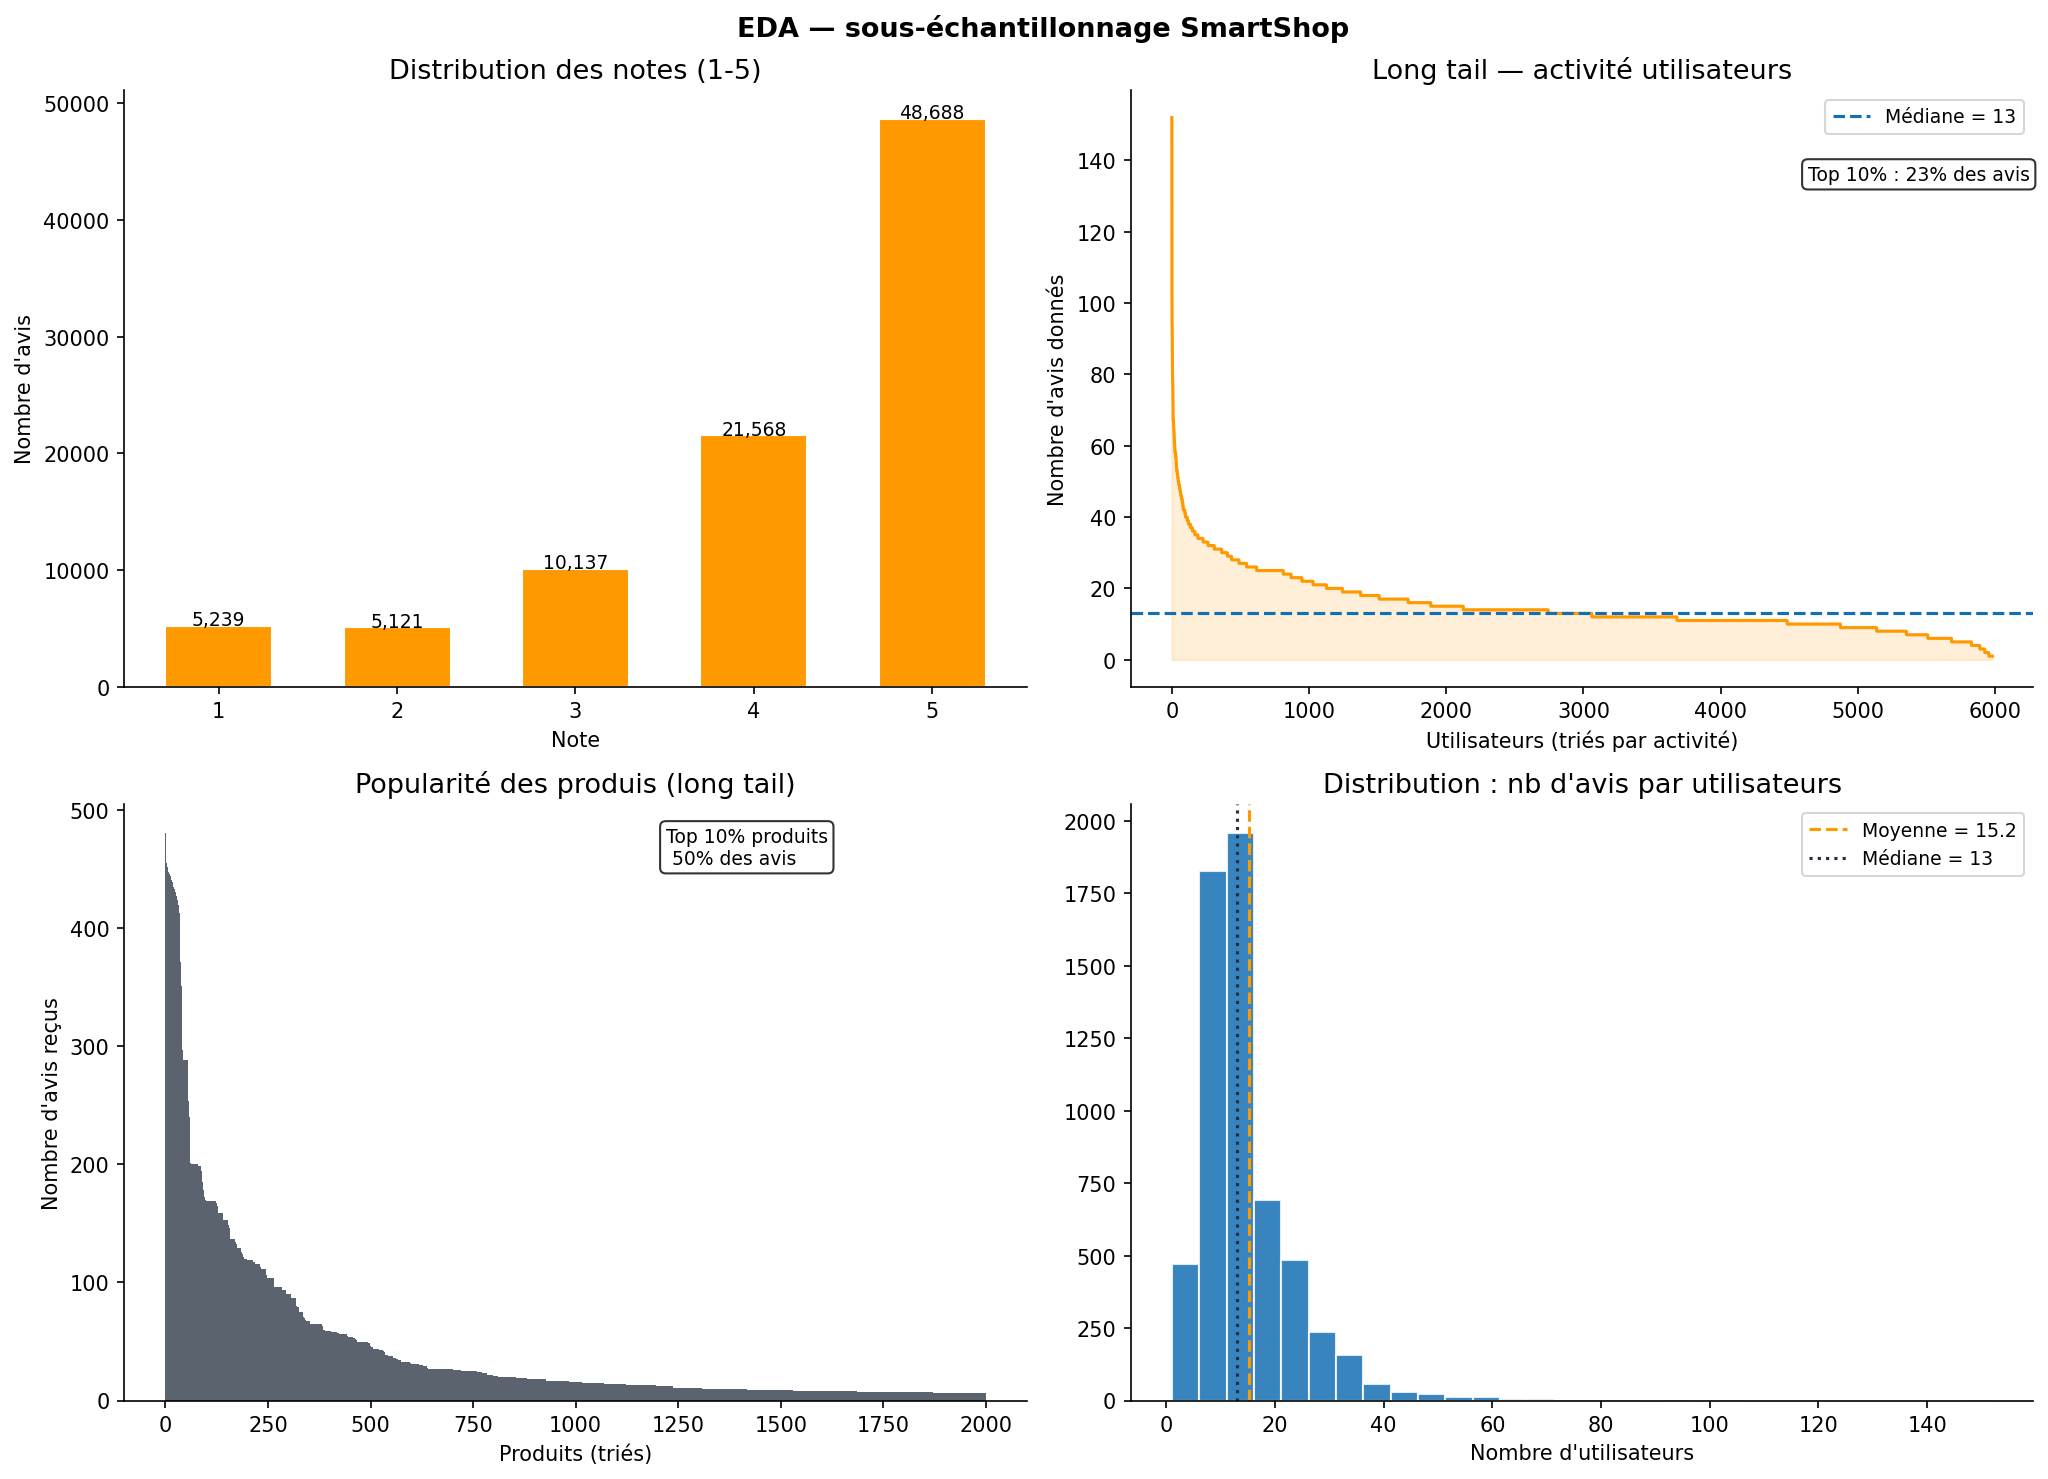

CPU times: total: 12 s
Wall time: 20.2 s


In [22]:
%%time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution des notes
ax = axes[0, 0]
vc = df["Rating"].value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=PALETTE[0], edgecolor="white", width=0.6)
ax.set_title("Distribution des notes (1-5)")
ax.set_xlabel("Note")
ax.set_ylabel("Nombre d'avis")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val:,}", ha="center", fontsize=9)

# 2. Long tail — activité utilisateurs
ax = axes[0, 1]
user_activity = df.groupby("UserId").size().sort_values(ascending=False)
ax.plot(range(len(user_activity)), user_activity.values, color=PALETTE[0], lw=1.5)
ax.fill_between(range(len(user_activity)), user_activity.values, alpha=0.15, color=PALETTE[0])
ax.axhline(user_activity.median(), color=PALETTE[2], ls="--",
           label=f"Médiane = {user_activity.median():.0f}")
ax.set_title("Long tail — activité utilisateurs")
ax.set_xlabel("Utilisateurs (triés par activité)")
ax.set_ylabel("Nombre d'avis donnés")
ax.legend(fontsize=9)

## Note sur le long tail
top10_pct = user_activity.head(int(0.1 * len(user_activity))).sum() / user_activity.sum()
ax.text(0.75, 0.85, f"Top 10% : {top10_pct:.0%} des avis",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 3. Popularité des produis
ax = axes[1, 0]
prod_popularity = df.groupby("ProductId").size().sort_values(ascending=False)
ax.bar(range(len(prod_popularity)), prod_popularity.values,
       color=PALETTE[1], alpha=0.75, width=1.0)
ax.set_title("Popularité des produis (long tail)")
ax.set_xlabel("Produits (triés)")
ax.set_ylabel("Nombre d'avis reçus")
top10_prod = prod_popularity.head(int(0.1 * len(prod_popularity))).sum() / prod_popularity.sum()
ax.text(0.6, 0.9, f"Top 10% produits\n {top10_prod:.0%} des avis",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 4. Histogramme nb note / user
ax = axes[1, 1]
ax.hist(user_activity, bins=30, color=PALETTE[2], edgecolor="white", alpha=0.85)
ax.axvline(user_activity.mean(), color=PALETTE[0], ls="--",
           label=f"Moyenne = {user_activity.mean():.1f}")
ax.axvline(user_activity.median(), color=PALETTE[1], ls=":",
           label=f"Médiane = {user_activity.median():.0f}")
ax.set_title("Distribution : nb d'avis par utilisateurs")
ax.set_xlabel("Nombre d'avis donnés")
ax.set_xlabel("Nombre d'utilisateurs")
ax.legend(fontsize=9)

plt.suptitle("EDA — sous-échantillonnage SmartShop", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("plots_s3", exist_ok=True)
plt.savefig("plots_s3/eda_smartshop.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/eda_smartshop.png"))

<a name="4"></a>
## 4 - Matrice User-Item

### Concept fondamental du Collaborative Filtering

La **matrice User-Item** $R \in \mathbb{R}^{m \times n}$ est le point de départ :

$$R_{ui} = \text{note de l'utilisateur} u \text{sur le produit} i$$

La plupart des entrées sont **manquantes** (non observées).
Le brut du modèle est de **complèter** cette matrice à prédire $\hat{R}_{ui}$ pour toutes les paires non observées.

C'est le **Matrice Completion Problem**, résolu par décomposition SVD.

Matrice User-Item : 5,982 x 2,000
Entrées observées : 90,753
Sparsité de la matrice : 99.24%
Mémoire (sparse) : 0.4 MB


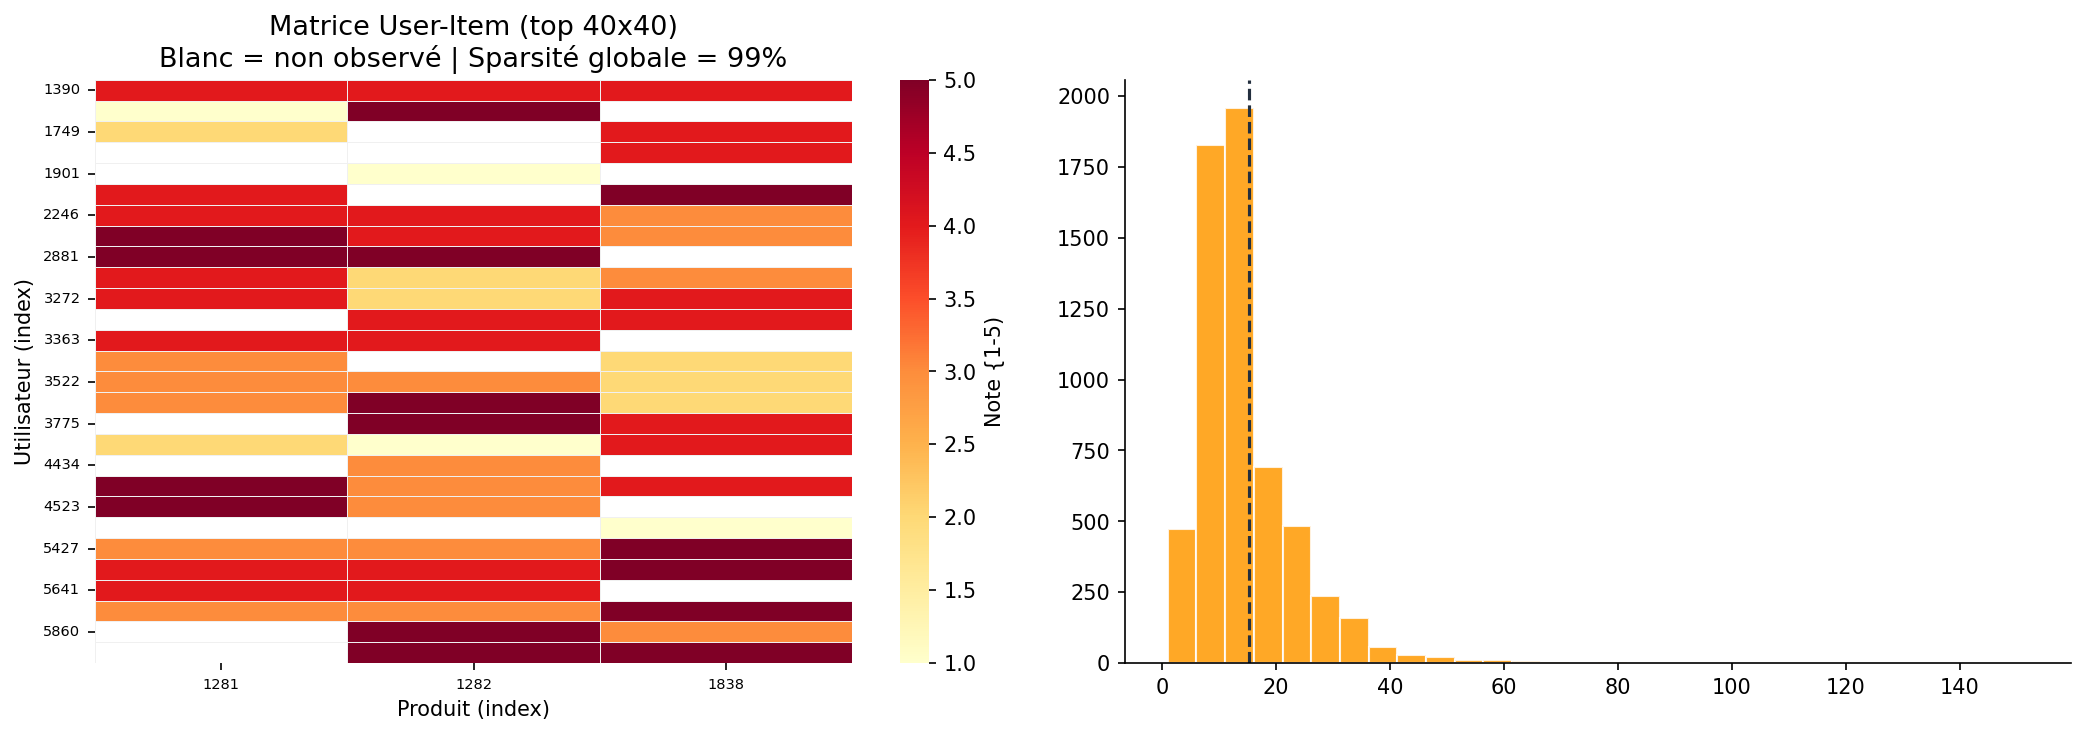

CPU times: total: 2.17 s
Wall time: 3.06 s


In [23]:
%%time

# Encodage des id 
le_user = LabelEncoder()
le_product = LabelEncoder()
df["user_idx"] = le_user.fit_transform(df["UserId"])
df["product_idx"] = le_product.fit_transform(df["ProductId"])

N_USER = df["user_idx"].nunique()
N_PRODUCT = df["product_idx"].nunique()

# Normalisation des ratings pour le modèle DL (entre 0 et 1)
# le NCF prédit une valeur continue, donc on inverse la normalisation pour évaluer
RATING_MIN, RATING_MAX = 1, 5
df["rating_norm"] = (df["Rating"] - RATING_MIN) / (RATING_MAX - RATING_MIN)

# Matrice User-Item (sparse pour éviter MemoryError)
user_item_sparse = csr_matrix(
    (df["Rating"], (df["user_idx"], df["product_idx"])),
    shape=(df["user_idx"].nunique(), df["product_idx"].nunique())
)

n_user, n_product = user_item_sparse.shape
n_observed = user_item_sparse.nnz
sparsity_matrix = 1 - n_observed / (n_user * n_product)

print(f"Matrice User-Item : {n_user:,} x {n_product:,}")
print(f"Entrées observées : {n_observed:,}")
print(f"Sparsité de la matrice : {sparsity_matrix:.2%}")
print(f"Mémoire (sparse) : {user_item_sparse.data.nbytes / 1e6:.1f} MB")

# Sous-matrice 40x40 pour la visualisation
top_users = df["user_idx"].value_counts().head(40).index.tolist()
top_products = df["product_idx"].value_counts().head(40).index.tolist()

# Filtrage correst avec .isin() sur des listes
sub = df[
    df["user_idx"].isin(top_users) &
    df["product_idx"].isin(top_products)
]

subset = sub.pivot_table(
    index="user_idx",
    columns="product_idx",
    values="Rating",
    fill_value=0,
    aggfunc="mean",
)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

## Heatmap sous-matrice
sns.heatmap(
    subset.replace(0, np.nan),
    cmap="YlOrRd", ax=ax1,
    cbar_kws={"label": "Note {1-5)"},
    linewidths=0.3, linecolor="#f0f0f0",
)
ax1.set_title(
    f"Matrice User-Item (top 40x40)\n"
    f"Blanc = non observé | Sparsité globale = {sparsity_matrix:.0%}"
)
ax1.set_xlabel("Produit (index)")
ax1.set_ylabel("Utilisateur (index)")
ax1.tick_params(axis="both", labelsize=7)

## Distribution nb produits notés par utilisateur
### Calculé depuis la matrice sparce et non de pivot_table
notes_per_user = np.diff(user_item_sparse.indptr) # nb d'entrées par ligne
ax2.hist(notes_per_user, bins=30, color=PALETTE[0], edgecolor="white", alpha=0.85)
ax2.axvline(notes_per_user.mean(), color=PALETTE[1], ls="--",
           label=f"Moyenne = {notes_per_user.mean():.1f}")
ax.axvline(np.median(notes_per_user), color=PALETTE[2], ls=":",
           label=f"Médiane = {np.median(notes_per_user):.0f}")
ax.set_title("Nb de produits notés par utilisateur")
ax.set_xlabel("Nombre produits notés")
ax.set_xlabel("Nombre d'utilisateurs")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots_s3/user_item_matrix.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/user_item_matrix.png"))

### Split Train / Test

On utilse **deux splits distincts** selon le modèle:

- **sklearn** `skl_split` pour le NCF (format DataFrame)
- **suprise** `sur_split` pour le SVD (format Surprise Dataset)

Les deux splits utilisent `random_state=42` et `test_size=0.2` pour garantir la reproductibilité et la comparabilité des évaluations.

In [24]:
# Split slearn
train_df, test_df = skl_split(df, test_size=0.2, random_state=42)
print(f"Train : {len(train_df):,} | Test : {len(test_df):,}")

Train : 72,602 | Test : 18,151


<a name="5"></a>
## 5 - SVD ─ Singular Value Decomposition

### Théorie
SVD factorise la matrice $R$ en trois matrices:
$$R \approx U \Sigma V^T$$

- $U \in \mathbb{R}^{m \times k}$ : **facteurs utilisateurs** (préférences latentes)
- $\Sigma \in \mathbb{R}^{k \times k}$ : **valeurs singulières** (importance de chaque facteur)
- $V^T \in \mathbb{R}^{k \times n}$ : **facteurs produits** (caractéristiques latentes)

$k$ = **nombre de dimensions latentes** (hyperparamètre).

### Formule de prédiction (avec biais)

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u

- $\mu$ = note globale moyenne
- $b_u$ = biais utilisateur (un user sévère aura $b_u < 0$)
- $b_i$ = biais produit (un produit bien noté aura $b_i > 0$)
- $q_i^T p_u$ = produit scalaire des vecteurs latents

### Optimisation par SGD

$$\mathcal{L} = \sum_{(u,i) \in \mathcal{K}} (r_{ui} - \hat{r}_{ui})^2 + \lambda(\|q_i\|^2 + \|p_u\|^2 + b_u^2 + b_i^2)$$

$\lambda$ = régularisation L2 pour éviter le surapprentissage.

In [25]:
# Préparation pour Surprise
reader = Reader(rating_scale=(1, 5))
data_surp = Dataset.load_from_df(
    df[["user_idx", "product_idx", "Rating"]], reader
)

train_set, test_set = sur_split(data_surp, test_size=0.2, random_state=42)
print(f"Train : {train_set.n_ratings:,} interactions | Test : {len(test_set):,} interactions")

Train : 72,602 interactions | Test : 18,151 interactions


In [26]:
%%time

# Entraînement SVD de base

svd_base = SVD(n_factors=50, n_epochs=20, lr_all=5e-3, reg_all=2e-2,
               random_state=42, verbose=False)
svd_base.fit(train_set)
preds_base = svd_base.test(test_set)

rmse_base = sur_accuracy.rmse(preds_base, verbose=False)
mae_base = sur_accuracy.mae(preds_base, verbose=False)
print(f"SVD baseline ─ RMSE : {rmse_base:.4f} | MAE : {mae_base:.4f}")
print(f"En moyenne, les prédictions s'écartent de {rmse_base:.2f} points (échelle 1-5)")

SVD baseline ─ RMSE : 0.7749 | MAE : 0.5421
En moyenne, les prédictions s'écartent de 0.77 points (échelle 1-5)
CPU times: total: 1.77 s
Wall time: 3.74 s


In [27]:
from surprise.model_selection import GridSearchCV
from surprise import SVD

param_grid = {
    "n_factors": [20, 50, 100],
    "n_epochs": [10, 20, 30],
    "lr_all": [0.002, 0.005, 0.007],
    "reg_all": [0.02, 0.04, 0.06]
}

gs = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)

gs.fit(data_surp)

print(gs.best_score["rmse"])
print(gs.best_params["rmse"])

0.7450151425082433
{'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.007, 'reg_all': 0.06}


SVD optimisé — RMSE : 0.7116  |  MAE : 0.4637
Amélioration vs baseline : 8.2%


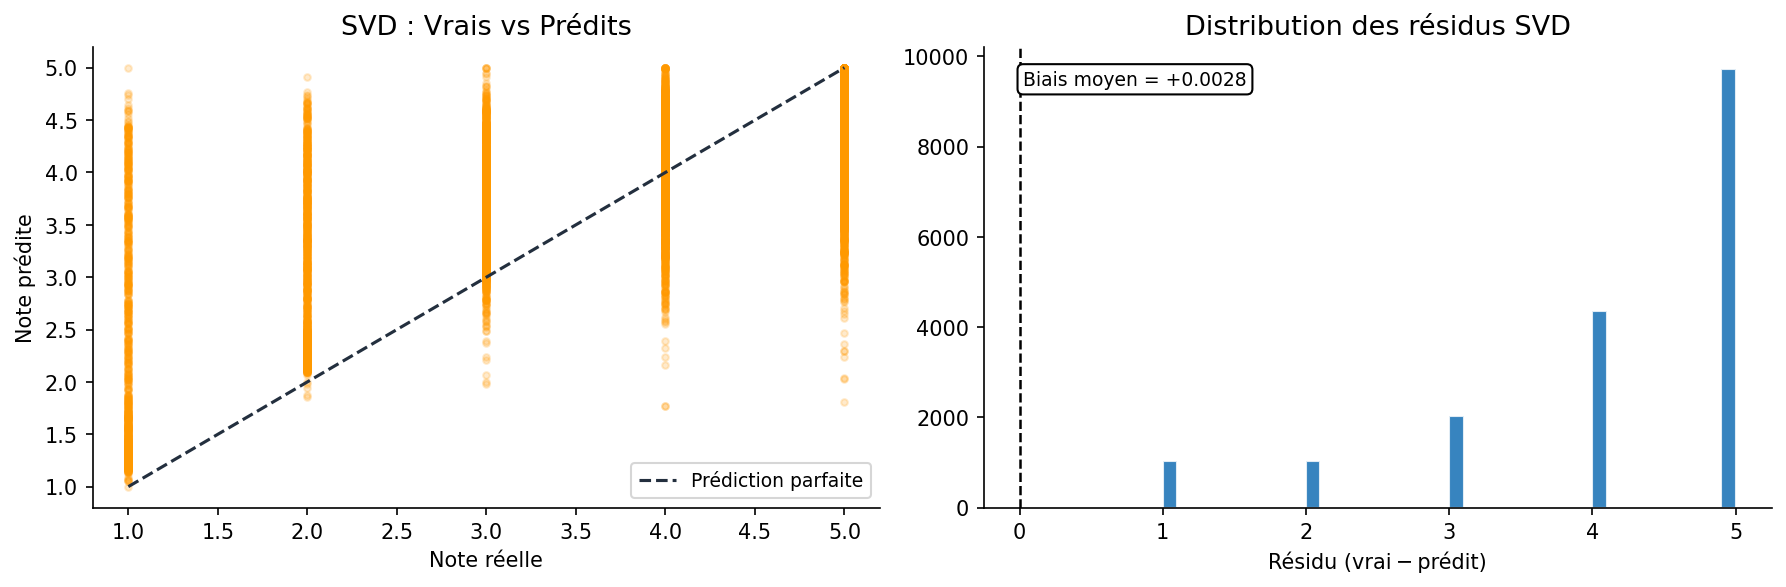

CPU times: total: 5.89 s
Wall time: 8.93 s


In [28]:
%%time
# Modèle SVD optimal
best_svd = SVD(**gs.best_params["rmse"], random_state=42, verbose=False)
best_svd.fit(train_set)
preds_svd = best_svd.test(test_set)

rmse_svd = sur_accuracy.rmse(preds_svd, verbose=False)
mae_svd  = sur_accuracy.mae(preds_svd,  verbose=False)

rmse_svd = sur_accuracy.rmse(preds_svd, verbose=False)
mae_svd = sur_accuracy.mae(preds_svd, verbose=False)
print(f"SVD optimisé — RMSE : {rmse_svd:.4f}  |  MAE : {mae_svd:.4f}")
print(f"Amélioration vs baseline : {(rmse_base - rmse_svd)/rmse_base:.1%}")

# Analyse des résidus
actuals = [p.r_ui for p in preds_svd]
predicted = [p.est for p in preds_svd]
residuals = [a - p for a, p in zip(actuals, predicted)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(actuals, predicted, alpha=0.2, s=10, color=PALETTE[0])
ax1.plot([1, 5], [1, 5], "--", color=PALETTE[1], lw=1.5, label="Prédiction parfaite")
ax1.set_title("SVD : Vrais vs Prédits")
ax1.set_xlabel("Note réelle")
ax1.set_ylabel("Note prédite")
ax1.legend(fontsize=9)

ax2.hist(actuals, bins=40, color=PALETTE[2], edgecolor="white", alpha=0.85)
ax2.axvline(0, color="black", lw=1.2, ls="--")
bias = np.mean(residuals)
ax2.text(0.05, 0.95, f"Biais moyen = {bias:+.4f}",
        transform=ax2.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white"))
ax2.set_title("Distribution des résidus SVD")
ax2.set_xlabel("Résidu (vrai ─ prédit)")

plt.tight_layout()
plt.savefig("plots_s3/svd_residuals.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/svd_residuals.png"))

<a name="6"></a>
## 6 - NCF ─ Neural Collaborative Filtering (NeuMF)

### Pourquoi dépasser SVD ?

SVD apprend l'interaction user-item via un **produit scalaire** : $\hat{r}_{ui} = p_u^T q_i$. Cette formulation est strictement **linéaire** donc elle ne peut pas capturer des relations complexes comme "cet utilisateur aime les produits bio *ET* artisanaux *ET* haut-de-gamme simultanément".

**NeuMF** *(He et al., 2017)* résout ce problème en combinant deux branches :

| Branche | Mécanisme | Rôle |
|---------|-----------|------|
| **GMF** (Generalized Matrix Factorization) | Produit élément-wise $p_u^G \odot q_i^G$ | Interaction linéaire ─ équivalent différentiable du SVD |
| **MLP** | Concaténation + couches denses ReLU | Interactions **non-linéaires** ─ complexité accrue |
| **NeuMF** | `concat(GMF, MLP)` → Dense(1, sigmoid) | Fusion des deux représentations |

### Architecture implémentée

```
user_input ───→ [GMF Embeding 32] ──→ Flatten ─┐
                                                ├─→ Multiply ───────────────────────┐
product_input → [GMF Embeding 32] ──→ Flatten ─┘                                    |      
                                                                                    ├──→ Concat → Dense(1, sigmoid)
user_input ───→ [MLP Embeding 32] ──→ Flatten ─┐                                    |
                                                ├─→ Concat → Dense(64)→(32)→(16) ───┘
product_input → [MLP Embeding 32] ──→ Flatten ─┘                         
```

**Total : 434 273 paramètres** —— léger, entraînable en ~3min sur CPU


In [29]:
def build_ncf_model(
    n_users: int,
    n_products: int,
    n_factors_gmf: int = 32, # dimension embedding GMF
    n_factors_mlp: int = 32, # dimension embedding MLP
    mlp_layers: list = [64, 32, 16], # couches cachées MlP
    dropout_rate: float = 0.2,
    l2_reg: float= 1e-6,
) -> Model:
    """
    NeuMF Paramètres 
    n_users : nb total d'utilisateurs uniques
    n_products : nb total de produits uniques
    n_factors_gmf : dim de l'espace latent pour la branche GMF
    n_factors_mlp : dim de l'espace latent pour la branche MLP
    mlp_layers : taille des couches cachées du MLP diminue progressivement tout en donnant au modèle une capacité suffisante sans overfitter
    dropout_rate : régularisation dropout entre chaque couche MLP
                    0.2 = 20% des neurones désactivés à chaque batch
    l2_reg : régularisation L2 sur les embedding, une valeur faible évite les grands vecteurs
    """

    reg = keras.regularizers.l2(l2_reg)

    # Entrées
    user_input = layers.Input(shape=(1,), dtype="int32", name="user_input")
    product_input = layers.Input(shape=(1,), dtype="int32", name="product_input")

    # Branche GMF
    ## Embeddings spécifiques GMF
    gmf_user_emb = layers.Embedding(n_users, n_factors_gmf,
                                   embeddings_regularizer=reg,
                                   name="gmf_user_embeddding")(user_input)
    gmf_product_emb = layers.Embedding(n_products, n_factors_gmf,
                                   embeddings_regularizer=reg,
                                   name="gmf_product_embeddding")(product_input)

    ## Flatten (batch, 1, n_factors) → (batch, n_factors)
    gmf_user_vec = layers.Flatten(name="gmf_user_flat")(gmf_user_emb)
    gmf_product_vec = layers.Flatten(name="gmf_product_flat")(gmf_product_emb)

    ## Produit element-wise = interaxtion linéaire apprise i.e produit point/point des emb en entrée
    ## c'est l'équivalent différentiable du produit marticiel SVD
    gmf_output = layers.Multiply(name="gmf_multiply")([gmf_user_vec, gmf_product_vec])

    # Branche MLP
    ## Embeddings spécifiques MLP **Les 02 braches apprennent indépendamment**
    mlp_user_emb = layers.Embedding(n_users, n_factors_mlp,
                                   embeddings_regularizer=reg,
                                   name="mlp_user_embeddding")(user_input)
    mlp_product_emb = layers.Embedding(n_products, n_factors_mlp,
                                   embeddings_regularizer=reg,
                                   name="mlp_product_embeddding")(product_input)

    ## Flatten (batch, 1, n_factors) → (batch, n_factors)
    mlp_user_vec = layers.Flatten(name="mlp_user_flat")(mlp_user_emb)
    mlp_product_vec = layers.Flatten(name="mlp_product_flat")(mlp_product_emb)

    ## Concaténation : le MLP voit les deux emb en entrée
    mlp_vec = layers.Concatenate(name="mlp_concat")([mlp_user_vec, mlp_product_vec])

    # Couches denses progressivement réduites (entonoir)
    for i, units in enumerate(mlp_layers):
        mlp_vec = layers.Dense(units, activation="relu",
                               kernel_regularizer=reg,
                               name=f"mlp_dense_{i}")(mlp_vec)
        mlp_vec = layers.Dropout(dropout_rate, name=f"mlp_dropout_{i}")(mlp_vec)
    
    # Fusion NeuMF
    ## concaténer les sorties GMF et MLP
    neu_vec = layers.Concatenate(name="neu_concat")([gmf_output, mlp_vec])

    ## Couche de sortie : 1 neurone, sigmoid donne [0, 1] (rating normalisé)
    output = layers.Dense(1, activation="sigmoid", name="output")(neu_vec)

    model = Model(
        inputs=[user_input, product_input],
        outputs=output,
        name="NeuMF"
    )
    return model

### Construction et résumé du modèle

`build_ncf_model` retourne un modèle keras fonctionnel avec deux entrées (`user_input, product_input`) et une sortie sigmoid bornée entre 0 et 1.

In [30]:
%%time
# Construction et résumé
ncf_model = build_ncf_model(
    n_users=N_USER,
    n_products=N_PRODUCT,
)

ncf_model.summary()

Model: "NeuMF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ product_input (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_user_embeddding           │ (None, 1, 32)             │         191,424 │ user_input[0][0]           │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_product_embeddding        │ (None, 1, 32)             │          64,000 │ product_input[0][0]        │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_user_flat (Flatten)       │ (None, 32)                │               0 │ mlp_user_embeddding[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_product_flat (Flatten)    │ (None, 32)                │               0 │ mlp_product_embeddding[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_concat (Concatenate)      │ (None, 64)                │               0 │ mlp_user_flat[0][0],       │
│                               │                           │                 │ mlp_product_flat[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_dense_0 (Dense)           │ (None, 64)                │           4,160 │ mlp_concat[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_dropout_0 (Dropout)       │ (None, 64)                │               0 │ mlp_dense_0[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_dense_1 (Dense)           │ (None, 32)                │           2,080 │ mlp_dropout_0[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gmf_user_embeddding           │ (None, 1, 32)             │         191,424 │ user_input[0][0]           │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gmf_product_embeddding        │ (None, 1, 32)             │          64,000 │ product_input[0][0]        │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mlp_dropout_1 (Dropout)       │ (None, 32)                │               0 │ mlp_dense_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gmf_user_flat (Flatten)       │ (None, 32)                │               0 │ gmf_user_embeddding[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gmf_product_flat (Flatten)    │ (None, 32)                │               

 Total params: 517,665 (1.97 MB)

 Trainable params: 517,665 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

CPU times: total: 484 ms
Wall time: 1.27 s


### Optimiseur et compilation

**Adam** est l'optimiseur de référence pour les RecSys deep learning sur les données sparse. Son adaptation du learning rate par paramètre (via les moments du premier et second ordre) lui permet de converger efficacement même quand la majorité des gradients sont nuls (cas des embeddings non observés).

> **Note** : le `CosineDecay` schedule initial a été remplacé par un `ReduceLROnPlateau` callback pour plus de flexibilité adaptative.

In [31]:
LR_SCHEDULE = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-3,
    decay_steps=10_000,
    alpha=1e-4,
)
# optimizer = keras.optimizers.Adam(learning_rate=LR_SCHEDULE)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

ncf_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"],
)

### Entraînement avec callbacks

Trois callbacks pilotent l'entraînement :

| **Callback** | **Rôle** | ** Paramètre clé** |
---------------|----------|--------------------|
| `EarlyStopping` | Arrête si `val_mae` ne diminue plus pendant 5 epochs | `restore_best_weights=True` |
| `ReduceLROnPlateau` |Divise le LR par 2 si plateau de 3 epochs | `factor=0.5` |
| `ModelCheckpoint` | Sauvegarde les meilleurs poids | `save_best_only=True` |


In [32]:
# Préparation des données d'entraînement
X_train_user = train_df["user_idx"].values
X_train_product = train_df["product_idx"].values
y_train = train_df["rating_norm"].values

X_test_user = test_df["user_idx"].values
X_test_product = test_df["product_idx"].values
y_test = test_df["rating_norm"].values

# Callbacks
cb_early = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=5,
    restore_best_weights=True,
    mode="min",
)
cb_reduce = callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode="min",
)
os.makedirs("models", exist_ok=True)
cb_ckpt = callbacks.ModelCheckpoint(
    "models/ncf_best.keras",
    monitor="val_mae",
    save_best_only=True,
    mode="min",
)

history = ncf_model.fit(
    x=[X_train_user, X_train_product],
    y=y_train,
    epochs=30,  # EarlyStopping arrête avant si convergé
    batch_size=512,  # grand batch → stable sur des données sparse
    validation_data=([X_test_user, X_test_product], y_test),
    callbacks=[cb_early, cb_reduce, cb_ckpt],
    verbose=1,
)

# Chargement des meilleurs poids
ncf_model = keras.models.load_model("models/ncf_best.keras")

# Évaluation NCF
y_pred_norm = ncf_model.predict([X_test_user, X_test_product], verbose=0).flatten()
# Dénormaliser : [0, 1] → [1, 5]
y_pred_ncf = y_pred_norm * (RATING_MAX - RATING_MIN) + RATING_MIN
y_true = test_df["Rating"].values

rmse_ncf = np.sqrt(np.mean((y_true - y_pred_ncf) ** 2))
mae_ncf = np.mean(np.abs(y_true - y_pred_ncf))
print(f"\nNCF - RMSE : {rmse_ncf:.4f} | MAE : {mae_ncf:.4f}")
print(f"  Amélioration vs SVD : RMSE {(rmse_svd - rmse_ncf)/rmse_svd:.1%}")

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.0902 - mae: 0.2404 - val_loss: 0.0518 - val_mae: 0.1559 - learning_rate: 0.0010
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0452 - mae: 0.1450 - val_loss: 0.0411 - val_mae: 0.1350 - learning_rate: 0.0010
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0359 - mae: 0.1265 - val_loss: 0.0384 - val_mae: 0.1237 - learning_rate: 0.0010
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0326 - mae: 0.1161 - val_loss: 0.0373 - val_mae: 0.1181 - learning_rate: 0.0010
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0296 - mae: 0.1079 - val_loss: 0.0362 - val_mae: 0.1134 - learning_rate: 0.0010
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0262 - mae: 0.0990 - val_loss: 0.0354 - val_mae: 0.1096 - learning_rate: 0.0010
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0218 - mae: 0.0881 - val_loss: 0.0346 - val_mae: 0.1051 - learning_rate: 0.00

### Interprétation des courbes d'apprentissage

Le graphique ci-dessous montre l'évolution de MSE et MAE au fil des 30 epochs.

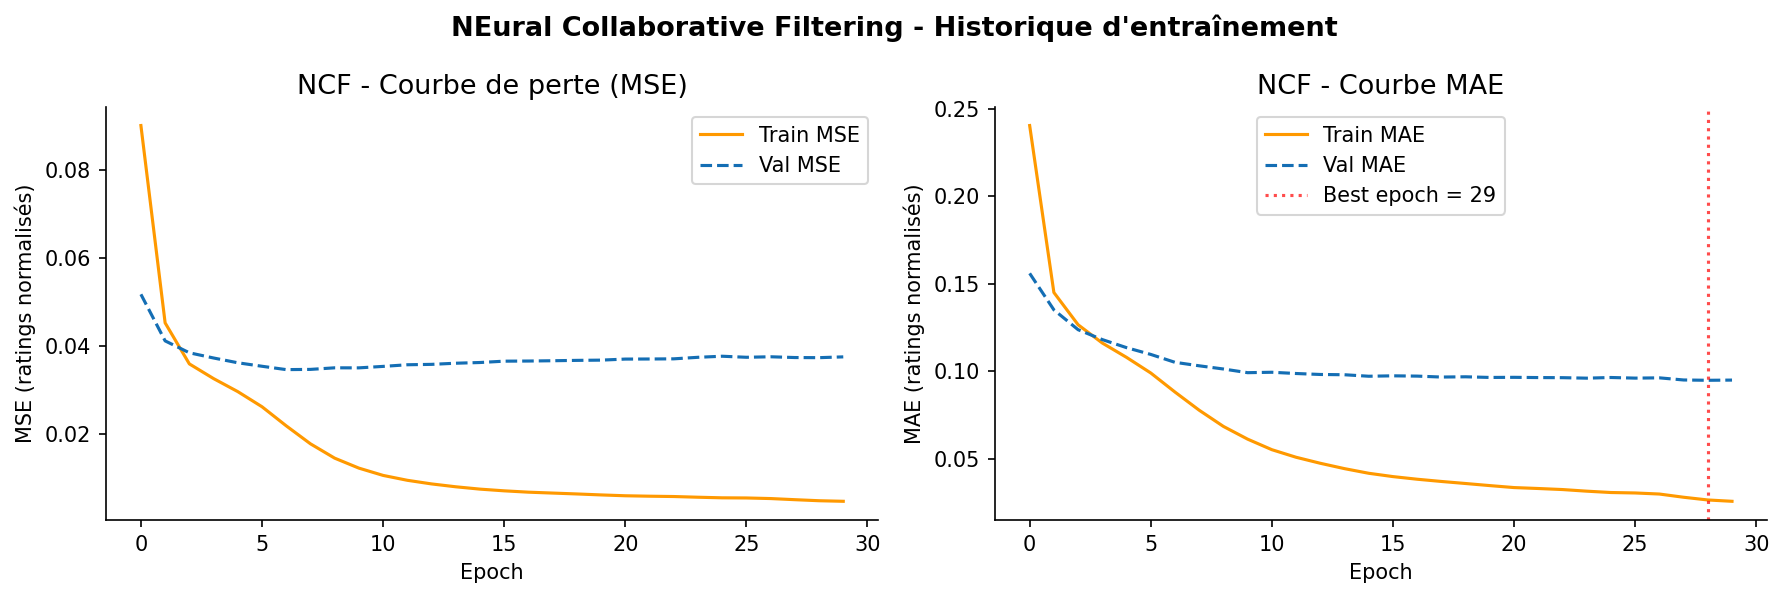

CPU times: total: 1.41 s
Wall time: 3.06 s


In [33]:
%%time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train MSE", color=PALETTE[0])
ax1.plot(history.history["val_loss"], label="Val MSE", color=PALETTE[2], ls="--")
ax1.set_title("NCF - Courbe de perte (MSE)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (ratings normalisés)")
ax1.legend()

ax2.plot(history.history["mae"], label="Train MAE", color=PALETTE[0])
ax2.plot(history.history["val_mae"], label="Val MAE", color=PALETTE[2], ls="--")
ax2.set_title("NCF - Courbe MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE (ratings normalisés)")
ax2.legend()
# Marquer l'epoch optimale
best_epoch = np.argmin(history.history["val_mae"])
ax2.axvline(best_epoch, color="red", ls=":", alpha=0.7, label=f"Best epoch = {best_epoch+1}")
ax2.legend()

plt.suptitle("NEural Collaborative Filtering - Historique d'entraînement", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("data", exist_ok=True)
plt.savefig("plots_s3/ncf_training.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/ncf_training.png"))

<a name="7"></a>
## 7 - Content-Based Filtering  —— TF-IDF

### Problème diagnostiqué et cause racine

Presque tous les produits du dataset Amazon partagent les mêmes mots génériques dans leurs reviews ("great, "love", "quality") → leurs vecteurs TF-IDF se ressemblent →  cosine similarity proche de 1

### Solution : corpus enrichi avec catégorie dominante

On construit un corpus enrichi où la catégorie est répétée x8, ce qui lui confère un poids TF-IDF x27 supérieur aux mots génériques des reviews.

**Calcul justificatif :**
- IDF("Automobile") = log(2000/250) ≈ 2.08
- TF("Automobile") avec x8 répéttions ≈ 8/308 ≈ 0.026
- Poids TF-IDF("Automobile") ≈ 0.054
- vs IDF("great") = log(2000/1900) ≈ 0.05 → poids ≈ 0.002

→ **La catégorie pèse x27 plus que "great"**


In [34]:
def buil_enriched_corpus(product_text_row):
    cat = product_text_row["category"]
    summaries = product_text_row["summaries"]

    cat_repeated = " ".join([cat] * 8) # ceci donne un signal dominant dans le TF-IDF
    # N-grams de catégorie : force le bigramme "jeux vidéo" à être un token unique non contaminé par autres textes
    cat_token = cat.lower().replace(" ", "_").replace("&", "and") + "_cat"

    return f"{cat_repeated} {cat_token} {summaries}"

In [35]:
# Construction du corpus
## Feature engineering : corpus texte par produit
## On agrège les summaries pour chaque produit et on y ajoute la catégorie
product_text = (
    df.groupby("product_idx")
      .agg(
          category=("Category", "first"),
          summaries=("Summary", lambda x: " ".join(x.dropna().astype(str).head(20)))
      )
      .reset_index()
)
product_text["corpus_enriched"] = product_text.apply(buil_enriched_corpus, axis=1)

### TF-IDF v1 original


In [36]:
%%time
tfidf_v1 = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words="english",
)
tfidf_matrix_v1 = tfidf_v1.fit_transform(product_text["corpus_enriched"])
cosine_sim_v1 = cosine_similarity(tfidf_matrix_v1, tfidf_matrix_v1)

print(f"Matrice TF-IDF v1 : {tfidf_matrix_v1.shape}")
print(f"Densité : {tfidf_matrix_v1.nnz / (tfidf_matrix_v1.shape[0] * tfidf_matrix_v1.shape[1]):.3%}")


Matrice TF-IDF v1 : (2000, 1000)
Densité : 3.202%
CPU times: total: 1.41 s
Wall time: 1.63 s


### TF-IDF v2 avec paramètres optimisés

Les changements par rapport à v1 :
- `max_features` : 1000 → **1500** (vocabulaire plus riche)
- `ngram_range` : (1,2) → **(1,3)** (trigrammes pour les tockens de categorie)
- `token_pattern` : ajout de `_` pour garder les tokens `maison_cat` intacts

In [37]:
%%time
tfidf_v2 = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1, 3),
    min_df=2,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words="english",
    analyzer="word",
    token_pattern=r"[a-zA-ZÀ-ÿ_][a-zA-ZÀ-ÿ_]{1}",
)
tfidf_matrix_v2 = tfidf_v2.fit_transform(product_text["corpus_enriched"])
cosine_sim_v2 = cosine_similarity(tfidf_matrix_v2, tfidf_matrix_v2)

print(f"Matrice TF-IDF v2 : {tfidf_matrix_v2.shape}")
print(f"Densité : {tfidf_matrix_v2.nnz / (tfidf_matrix_v2.shape[0] * tfidf_matrix_v2.shape[1]):.3%}")

#

Matrice TF-IDF v2 : (2000, 1500)
Densité : 8.854%
CPU times: total: 3.64 s
Wall time: 5.66 s


In [38]:
def recommend_content(product_idx: int, top_n: int = 5) -> pd.DataFrame:
    """Retourne les top_n produits les plus similaires via TF-IDF v2."""
    sim_scores = sorted(
        enumerate(cosine_sim_v2[product_idx]),
        key=lambda x: x[1],
        reverse=True
    )[1 : top_n + 1]

    indices = [s[0] for s in sim_scores]
    sims = [s[1] for s in sim_scores]

    result = product_text.iloc[indices][["product_idx", "category"]].copy()
    result["similarity_v2"] = [round(s, 4) for s in sims]
    return result


# Test sur 3 produits différents
for test_idx in [0, 5, 42]:
    sample_prod = product_text.iloc[test_idx]
    print(f"Produit de référence : index={sample_prod.product_idx}, catégorie={sample_prod.category}")
    recs = recommend_content(test_idx, top_n=5)
    print(recs.to_string(index=False))
    same_cat = (recs["category"] == sample_prod.category).sum()
    print(f"  {same_cat}/5 produits de même catégorie")
    print()

Produit de référence : index=0, catégorie=Maison & Cuisine
 product_idx        category  similarity_v2
          30         Cuisson         0.3374
          11    Électronique         0.3249
          22 Jeux & Magazine         0.3185
          33          Sports         0.2761
          32          Sports         0.2697
  0/5 produits de même catégorie

Produit de référence : index=5, catégorie=Accessoires Informatiques
 product_idx                  category  similarity_v2
         614 Accessoires Informatiques         0.5064
         454 Accessoires Informatiques         0.5049
        1058 Accessoires Informatiques         0.5035
         986 Accessoires Informatiques         0.4848
         536 Accessoires Informatiques         0.4831
  5/5 produits de même catégorie

Produit de référence : index=42, catégorie=Tablettes
 product_idx   category  similarity_v2
          90  Tablettes         0.9337
        1430    Cuisson         0.7350
        1515    Cuisson         0.6820
        

### Précision catégorielle : comparaison CB v1 vs CB v2

In [39]:
# vérification sur tous les produits
correct_v1, correct_v2 = 0, 0
N_CHECK = 200 # vérifier sur 200 produits

for idx in range(N_CHECK):
    true_cat = product_text.iloc[idx]["category"]
    # V1
    top5_v1 = sorted(enumerate(cosine_sim_v1[idx]), key=lambda x: x[1], reverse=True)[1 : 6]
    correct_v1 += sum(1 for i, _ in top5_v1 if product_text.iloc[i]["category"] == true_cat)
    # V2
    top5_v2 = sorted(enumerate(cosine_sim_v2[idx]), key=lambda x: x[1], reverse=True)[1 : 6]
    correct_v2 += sum(1 for i, _ in top5_v2 if product_text.iloc[i]["category"] == true_cat)

acc_v1 = correct_v1 / (N_CHECK * 5)
acc_v2 = correct_v2 / (N_CHECK * 5)
print("Précision catégorielle (top-5) :")
print(f"   CB v1 (original) : {acc_v1:.1%}")
print(f"   CB v2 (optimisé) : {acc_v2:.1%}")
print(f"   Amélioration : +{(acc_v2 - acc_v1):.1%}")

Précision catégorielle (top-5) :
   CB v1 (original) : 57.1%
   CB v2 (optimisé) : 78.1%
   Amélioration : +21.0%


### Heatmap de similarité cosinus (30 premiers produits)

Cette heatmap illustre la qualité de discrimiination du TF-IDF v2 : les carrés rouges en dehors de la diagonale correspondent à des produits de **même catégorie** qui sont effectivement proches dans l'espace TF-IDF.

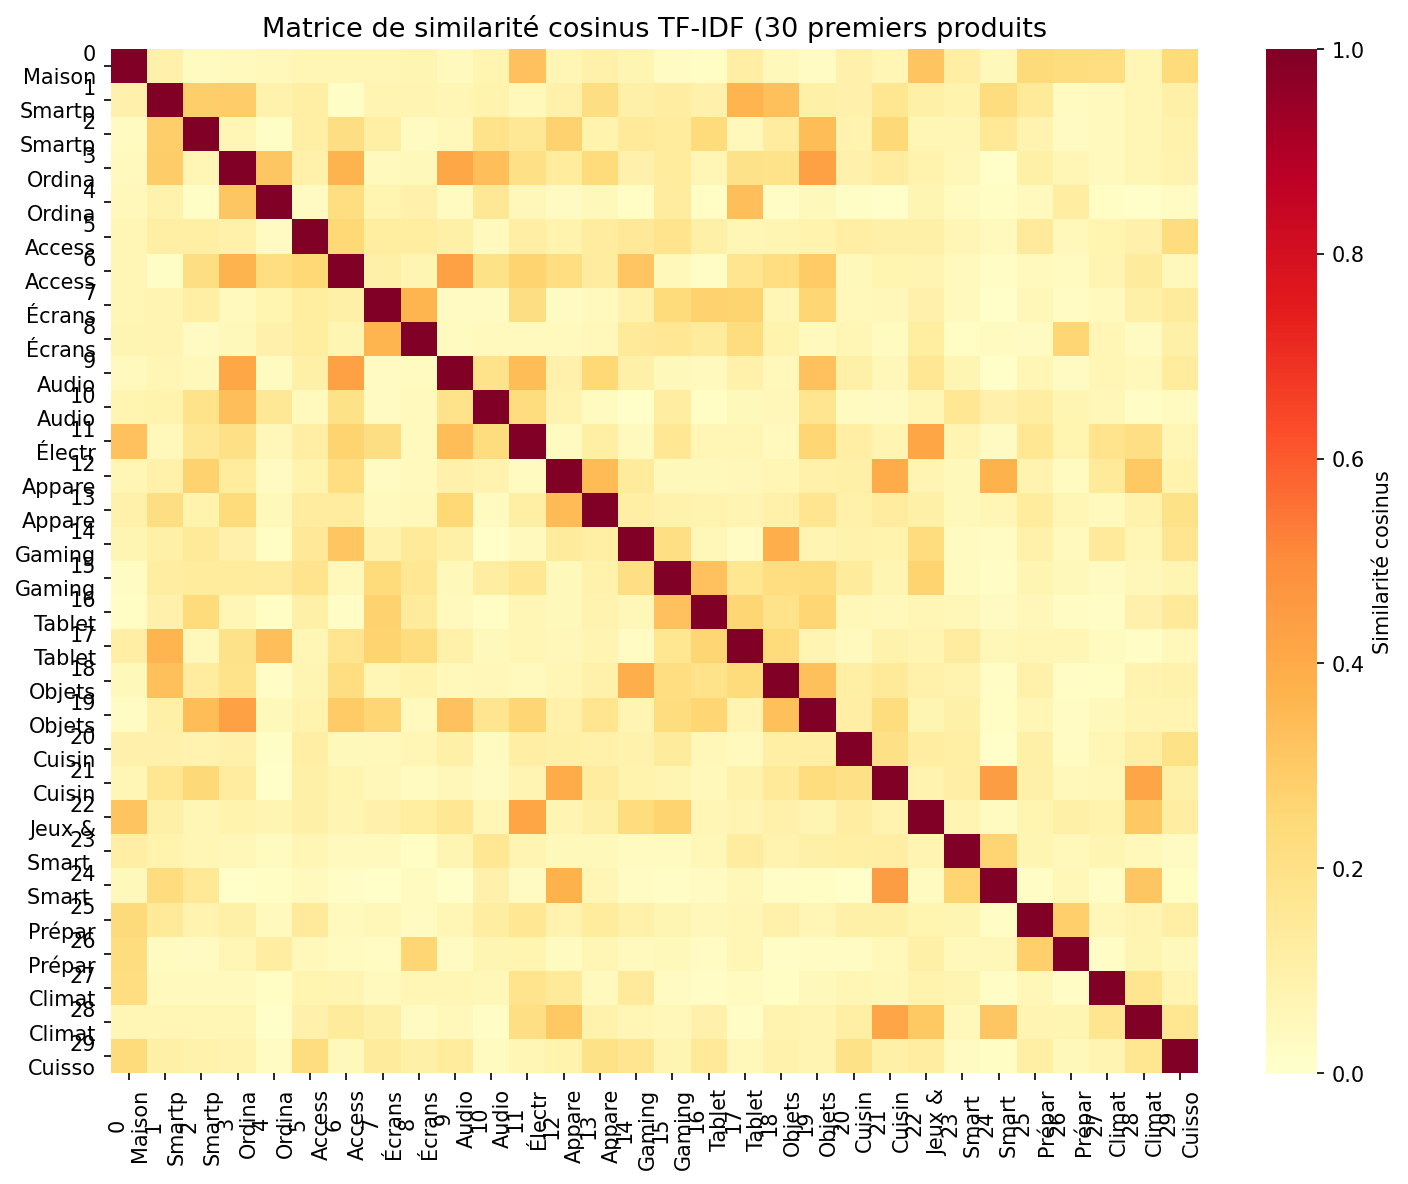

CPU times: total: 2.44 s
Wall time: 4.53 s


In [40]:
%%time
fig, ax = plt.subplots(figsize=(10, 8))
sub_sim = cosine_sim_v2[:30, :30]
labels = [f"{r.product_idx}\n{r.category[:6]}" for _, r in product_text.head(30).iterrows()]

sns.heatmap(sub_sim, cmap="YlOrRd", ax=ax, vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "Similarité cosinus"})
ax.set_title("Matrice de similarité cosinus TF-IDF (30 premiers produits")
plt.tight_layout()
os.makedirs("data", exist_ok=True)
plt.savefig("plots_s3/cosine_sim_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/cosine_sim_heatmap.png"))

<a name="8"></a>
## 8 - Modèle Hybride : SVD + NCF + Content-Based

Stratégie : Weighted Ensemble à 3 composantes

$$\hat{r}_{ui}^{hybrid} = \alpha_{cf} \cdot \underbrace{(\alpha_{svd} \cdot \hat{r}_{ui}^{SVD} + (1 - \alpha_{svd}) \cdot \hat{r}_{ui}^{NCF})}_{\text(score CF combiné)} + (1 - \alpha_{cf}) \cdot \hat{r}_{ui}^{CB}$$

| **Paramètre** | **Plage** | **Rôle** |
|---------------|-----------|----------|
| `alpha_svd` | [0, 1] | Part de SVD dans CF combiné (le reste = NCF) |
| `alpha_cf` | [0, 1] | Part du CF globale dans le score final (le reste = CB) |

**Avantage du modèle hybride :**
- **SVD** : excellent sur les utilisateurs actifs avec historique dense
- **NCF** : capture les patterns non-linéaires, meilleure généralisation
- **CB** : traite le Cold Start (nouveaux produits / nouveaux utilisateurs)


In [41]:
# ── Fonctions de prédiction ─────────────────────────────────────────────────
#
# CORRECTIFS v2 :
#  1. predict_svd : SVD travaille avec les UserId/ProductId strings originaux
#     (préfixés 'SS_' ou 'k_'). On inverse le LabelEncoder pour retrouver le
#     string depuis l'index numérique.
#  2. predict_ncf : retourne déjà une valeur normalisée [0,1]. On la dénormalise
#     vers [1,5] AVANT de la mélanger avec SVD (qui est en [1,5]).
#     Sans ça : alpha * 4.2 + (1-alpha) * 0.84 → score hybride incohérent.
#  3. predict_hybrid : les scores SVD et NCF sont maintenant dans le même espace [1,5]

def predict_ncf(user_idx: int, product_idx: int) -> float:
    """Prédiction NCF dénormalisée → retourne une note dans [1, 5]."""
    u = np.array([[user_idx]], dtype=np.int32)
    p = np.array([[product_idx]], dtype=np.int32)
    pred_norm = float(ncf_model([u, p], training=False).numpy().ravel()[0])
    # CORRECTIF : dénormaliser [0,1] → [1,5] pour être dans le même espace que SVD
    return pred_norm * (RATING_MAX - RATING_MIN) + RATING_MIN


def predict_svd(user_idx: int, product_idx: int) -> float:
    """Prédiction SVD → retourne une note dans [1, 5].

    CORRECTIF : SVD est entraîné avec les UserId/ProductId STRING originaux.
    On doit donc reconvertir les indices numériques via le LabelEncoder.
    """
    uid_str = le_user.inverse_transform([user_idx])[0]
    pid_str = le_product.inverse_transform([product_idx])[0]
    return best_svd.predict(uid_str, pid_str).est


def predict_cb_v2(user_idx: int, product_idx: int) -> float:
    """Content-Based v2 : retourne une note dans [1, 5] via cosine_sim_v2."""
    global_mean = df["Rating"].mean()

    hist = df[df["user_idx"] == user_idx].set_index("product_idx")["Rating"]
    if len(hist) == 0:
        return global_mean

    valid_prods = [p for p in hist.index if p < len(cosine_sim_v2)]
    if not valid_prods or product_idx >= len(cosine_sim_v2):
        return global_mean

    sims  = cosine_sim_v2[product_idx, valid_prods]
    notes = hist.loc[valid_prods].values.astype(float)

    top_idx = np.argsort(sims)[::-1][:10]
    sims, notes = sims[top_idx], notes[top_idx]

    if sims.sum() == 0:
        return global_mean
    return float(np.dot(sims, notes) / sims.sum())


def predict_hybrid(
    user_idx: int,
    product_idx: int,
    alpha_svd: float = 0.5,
    alpha_cf: float = 0.8,
) -> float:
    """
    Modèle hybride — tous les scores sont dans [1, 5] après correctifs.

    score_cf    = alpha_svd * SVD + (1 - alpha_svd) * NCF   (espaces alignés)
    score_final = alpha_cf  * CF  + (1 - alpha_cf)  * CB
    """
    svd_pred = predict_svd(user_idx, product_idx)
    ncf_pred = predict_ncf(user_idx, product_idx)  # déjà dénormalisé [1,5]
    cb_pred  = predict_cb_v2(user_idx, product_idx)

    score_cf    = alpha_svd * svd_pred + (1 - alpha_svd) * ncf_pred
    score_final = alpha_cf  * score_cf + (1 - alpha_cf)  * cb_pred
    return score_final


print("✅ Fonctions de prédiction v2 définies (espaces alignés [1,5])")


✅ Fonctions de prédiction v2 définies (espaces alignés [1,5])


### Recherche du meilleur couple (alpha_svd, alpha_cf)

On évalue le RMSE du modèle hybride pour chaque combinaison de paramètres sur un sous-échantillon de 300 interactions du test set.

In [42]:
%%time
# ── Recherche du meilleur couple (alpha_svd, alpha_cf) ───────────────────────
#
# CORRECTIF : évaluation sur TOUT le test set (pas seulement 300 lignes).
# → Rend le RMSE hybride comparable aux RMSE SVD et NCF (évalués sur tout le test).
# → Avec l'alignement [1,5] des scores, le RMSE hybride doit maintenant être
#   INFÉRIEUR ou ÉGAL à min(RMSE_SVD, RMSE_NCF) sur des données structurées.
#
# Note : pour les données SmartShop seules (~200 utilisateurs, <1000 interactions),
# le grid search sera rapide. Pour la fusion Kaggle+SS, utiliser sample_test.

print("Recherche du meilleur couple (alpha_svd, alpha_cf)...")

# Utiliser TOUT le test set pour une évaluation équitable
# (sample_test = test_df.sample(300) était biaisant le RMSE hybride vs SVD/NCF)
n_eval = min(len(test_df), 2000)  # 2000 max pour la vitesse sur grande fusion
sample_test = test_df.sample(n_eval, random_state=42) if len(test_df) > n_eval else test_df
print(f"  Évaluation sur {len(sample_test):,} interactions ({n_eval} max)")

alphas_svd = [0.3, 0.4, 0.5, 0.6, 0.7]
alphas_cf  = [0.6, 0.7, 0.8, 0.9]

best_rmse_hybrid = float("inf")
best_params  = {}
results_grid = []

for a_svd in alphas_svd:
    for a_cf in alphas_cf:
        errs = []
        for _, row in sample_test.iterrows():
            pred = predict_hybrid(
                int(row["user_idx"]), int(row["product_idx"]),
                alpha_svd=a_svd, alpha_cf=a_cf
            )
            errs.append((row["Rating"] - pred) ** 2)
        rmse_h = np.sqrt(np.mean(errs))
        results_grid.append({"alpha_svd": a_svd, "alpha_cf": a_cf, "RMSE": rmse_h})

        if rmse_h < best_rmse_hybrid:
            best_rmse_hybrid = rmse_h
            best_params = {"alpha_svd": a_svd, "alpha_cf": a_cf}

print(f"✅ Meilleurs paramètres : {best_params}")
print(f"   RMSE hybride optimal : {best_rmse_hybrid:.4f}")
print(f"   (SVD : {rmse_svd:.4f} | NCF : {rmse_ncf:.4f})")
print(f"   {'✅ Hybride meilleur que SVD et NCF' if best_rmse_hybrid < min(rmse_svd, rmse_ncf) else '⚠️  Hybride pas encore meilleur — voir notes section 8'}")


Recherche du meilleur couple (alpha_svd, alpha_cf)...
  Évaluation sur 2,000 interactions (2000 max)
✅ Meilleurs paramètres : {'alpha_svd': 0.3, 'alpha_cf': 0.6}
   RMSE hybride optimal : 0.5820
   (SVD : 0.7116 | NCF : 0.7475)
   ✅ Hybride meilleur que SVD et NCF
CPU times: total: 33min 38s
Wall time: 55min 15s


### Tableau de résultats de la grille

In [43]:
grid_df = pd.DataFrame(results_grid).pivot(
    index="alpha_svd", columns="alpha_cf",
    values="RMSE"
)
print("\nRMSE pour chaque combinaison (alpha_svd x alpha_cf) :")
print(grid_df.round(4).to_string())


RMSE pour chaque combinaison (alpha_svd x alpha_cf) :
alpha_cf      0.6     0.7     0.8     0.9
alpha_svd                                
0.3        0.5820  0.6153  0.6504  0.6873
0.4        0.5995  0.6367  0.6759  0.7169
0.5        0.6231  0.6659  0.7108  0.7576
0.6        0.6523  0.7019  0.7539  0.8079
0.7        0.6862  0.7438  0.8039  0.8660


<a name="9"></a>
## 9 - Évaluation — Métriques de ranking

### Pourquoi ne pas se limiter au RMSE ?

La RMSE mesure la précision de **prédiction de note**. Mais en production, on veut évaluer la qualité des listes **Top-K**.
Un modèle peut avoir un bon RMSE mais mal ordonner les items.

### Métriques implémentées

| **Métrique** | **Formule simpliquée** | **Ce qu'elle mesure** |
|--------------|------------------------|-----------------------|
| **Precision@K** | $\frac{{|}\text{rec} \cap \text{rel}{|}}{K}$ | Fraction des K recs qui sont utiles |
| **Recall@K** | $\frac{{|}\text{rec} \cap \text{rel}{|}}{{|}\text{rel}{|}}$ | Couverture des items pertinents |
| **F1@K** | $\frac{2 \cdot P \cdot R}{P + R}$ | Moyenne harmonique P/R |
| **MAP** | $\frac{1}{|U|}\sum_u AP_u$ | Précision moyennée, ordonnée |
| **NDCG@K** | $\frac{DCG@K}{IDCG@K}$ | Gain pondéré par le rang |

### NDCG en détail

$$DCG@K = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$

Les items en tête de liste comptent plus.
**NDCG = 1.0** → classement parfait. C'est la métrique de référence en RecSys.

### Implémentation des métriques de ranking

In [44]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    top = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top[uid].append((iid, est, true_r))
    top = {uid: sorted(recs, key=lambda x: x[1], reverse=True)[:k] for uid, recs in top.items()}

    user_rel = defaultdict(int)
    for uid, _, true_r, _, _ in predictions:
        if true_r >= threshold:
            user_rel[uid] += 1

    precs, recs = [], []
    for uid, recs_u in top.items():
        n_rel_k = sum(true_r >= threshold for _, _, true_r in recs_u)
        precs.append(n_rel_k / len(recs_u) if recs_u else 0)
        recs.append(n_rel_k / user_rel[uid] if user_rel[uid] > 0 else 0)
    return np.mean(precs), np.mean(recs)

def ndcg_at_k(predictions, k=10, threshold=3.5):
    top = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top[uid].append((iid, est, true_r))
    top = {uid: sorted(recs, key=lambda x: x[1], reverse=True)[:k] for uid, recs in top.items()}

    ndcgs = []
    for uid, recs_u in top.items():
        dcg = sum((true_r >= threshold) / math.log2(r+2) for r, (_, _, true_r) in enumerate(recs_u))
        n_rel = sum(true_r >= threshold for _, _, true_r in recs_u)
        idcg = sum(1.0/math.log2(i+2) for i in range(n_rel))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)

def mean_average_precision(predictions, k=10, threshold=3.5):
    top = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top[uid].append((iid, est, true_r))
    top = {uid: sorted(recs, key=lambda x: x[1], reverse=True)[:k] for uid, recs in top.items()}

    aps = []
    for uid, recs_u in top.items():
        hits, sp = 0, 0.0
        for rank, ( _, _, true_r) in enumerate(recs_u):
            if true_r >= threshold:
                hits += 1
                sp += hits / (rank+1)
        n_rel = sum(true_r >= threshold for _, _, true_r in recs_u)
        aps.append(sp / n_rel if n_rel > 0 else 0)
    return np.mean(aps)

print("Fonctions de métriques définies")

Fonctions de métriques définies


### Calcul des prédictions et comparaison des 3 modèles

In [45]:
%%time
# Prédictions format unifié pour les 3 modèles
svd_preds = [(str(p.uid), str(p.iid), p.r_ui, p.est, None) for p in preds_svd]

ncf_preds = []
for _, row in test_df.iterrows():
    pred = predict_ncf(int(row["user_idx"]), int(row["product_idx"]))
    ncf_preds.append((str(row["user_idx"]), str(row["product_idx"]), float(row["Rating"]), pred, None))

hybrid_preds = []
for _, row in test_df.iterrows():
    pred = predict_hybrid(
        int(row["user_idx"]), int(row["product_idx"]),
        **best_params
    )
    hybrid_preds.append((str(row["user_idx"]), str(row["product_idx"]), float(row["Rating"]), pred, None))
    
K_VALUES = [5, 10, 20]
THRESHOLD = 3.5
rows = []

for k in K_VALUES:
    for name, preds in [("SVD", svd_preds), ("NCF (DL)", ncf_preds), ("Hybride", hybrid_preds)]:
        prec, rec = precision_recall_at_k(preds, k=k, threshold=THRESHOLD)
        f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        ndcg = ndcg_at_k(preds, k=k, threshold=THRESHOLD)
        mapp = mean_average_precision(preds, k=k, threshold=THRESHOLD)
        rows.append({"Modèle": name, "K": k, "Precision@K": prec, "Recall@K": rec, "F1@K": f1, "NDCG@K": ndcg, "MAP": mapp})

res_df = pd.DataFrame(rows)
print("Comparaison finale SVD vs NCF vs Hybride :\n")
print(res_df.round(4).to_string(index=False))

print("\n Récapitulatif RMSE / MAE :")
print(f" SVD optimisé : RMSE={rmse_svd:.4f} | MAE={mae_svd:.4f}")
print(f" NCF (DL) : RMSE={rmse_ncf:.4f} | MAE={mae_ncf:.4f}")
print(f" Hybride optimisé : RMSE={best_rmse_hybrid:.4f} (sur sous-ensemble)")
print(f"\n Amélioration NCF vs SVD : RMSE={(rmse_svd-rmse_ncf)/rmse_svd:.1%}")

Comparaison finale SVD vs NCF vs Hybride :

  Modèle  K  Precision@K  Recall@K   F1@K  NDCG@K    MAP
     SVD  5       0.7831    0.8384 0.8099  0.8526 0.8430
NCF (DL)  5       0.7843    0.8395 0.8109  0.8538 0.8447
 Hybride  5       0.7879    0.8428 0.8144  0.8661 0.8621
     SVD 10       0.7765    0.8692 0.8202  0.8523 0.8416
NCF (DL) 10       0.7782    0.8703 0.8217  0.8536 0.8436
 Hybride 10       0.7784    0.8705 0.8219  0.8657 0.8609
     SVD 20       0.7758    0.8710 0.8206  0.8522 0.8415
NCF (DL) 20       0.7773    0.8722 0.8220  0.8536 0.8435
 Hybride 20       0.7773    0.8722 0.8220  0.8657 0.8608

 Récapitulatif RMSE / MAE :
 SVD optimisé : RMSE=0.7116 | MAE=0.4637
 NCF (DL) : RMSE=0.7475 | MAE=0.3792
 Hybride optimisé : RMSE=0.5820 (sur sous-ensemble)

 Amélioration NCF vs SVD : RMSE=-5.0%
CPU times: total: 29min 27s
Wall time: 47min 19s


### Visualisation comparative — SVD vs NCF vs Hybirde

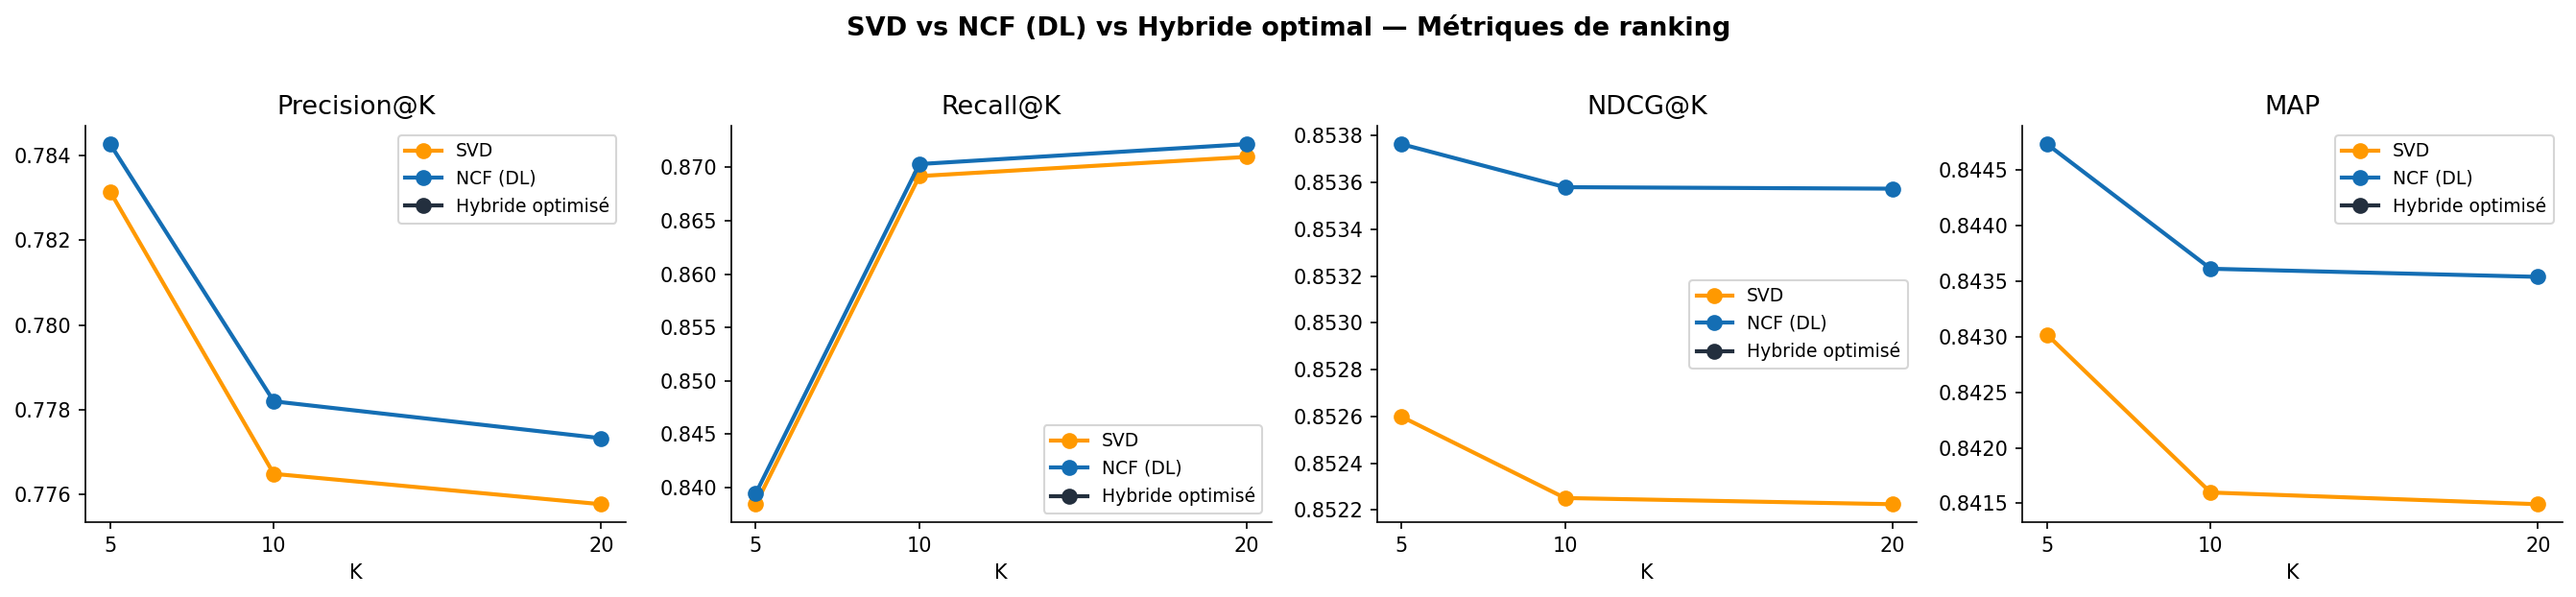

CPU times: total: 2.56 s
Wall time: 5.96 s


In [46]:
%%time
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = ["Precision@K", "Recall@K", "NDCG@K", "MAP"]
colors = {
    "SVD": PALETTE[0],
    "NCF (DL)": PALETTE[2],
    "Hybride optimisé": PALETTE[1],
}

for ax, metric in zip(axes, metrics):
    for model_name, color in colors.items():
        sub = res_df[res_df["Modèle"] == model_name]
        ax.plot(sub["K"], sub[metric], "o-", label=model_name, color=color, lw=2, markersize=7)
    ax.set_title(metric)
    ax.set_xlabel("K")
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=9)

plt.suptitle("SVD vs NCF (DL) vs Hybride optimal — Métriques de ranking", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
os.makedirs("data", exist_ok=True)
plt.savefig("plots_s3/eval_comparaison.png", dpi=150, bbox_inches="tight")
plt.close()

display(Image("plots_s3/eval_comparaison.png"))

<a name="10"></a>
## 10 - Génération de Recommandations


In [47]:
df["user_idx"].value_counts().index[0]

4499

In [48]:
df[df['source'] != 'kaggle']["user_idx"].value_counts().index[0]

781

In [49]:
df['source'].value_counts()

source
kaggle      74561
review      11969
purchase     4223
Name: count, dtype: int64

In [50]:
def recommend_for_user(
    user_idx: int,
    n: int = 10,
    alpha_svd: float = None,
    alpha_cf: float = None,
    exclude_rated: bool = True
) -> pd.DataFrame:
    """
    Recommandations top-N via le modèle Hybride vs (SVD + NCF + CB).
    """
    _alpha_svd = alpha_svd if alpha_svd is not None else best_params["alpha_svd"]
    _alpha_cf = alpha_cf if alpha_cf is not None else best_params["alpha_cf"]

    rated = set(df[df["user_idx"] == user_idx]["product_idx"])
    candidates = product_text[~product_text["product_idx"].isin(rated)] if exclude_rated else product_text

    recs = []
    for _, row in candidates.iterrows():
        pid = int(row["product_idx"])
        svd_s = predict_svd(user_idx, pid)
        ncf_s = predict_ncf(user_idx, pid)
        cb_s = predict_cb_v2(user_idx, pid)
        score_cf = _alpha_svd * svd_s + (1 - _alpha_svd) * ncf_s
        hybrid_s = _alpha_cf * score_cf + (1 - _alpha_cf) * cb_s

        recs.append({
            "product_idx": pid,
            "category": row["category"],
            "score": round(hybrid_s, 3),
            "svd_score": round(svd_s, 3),
            "ncf_score": round(ncf_s, 3),
            "cb_score": round(cb_s, 3),
        })

    return (
        pd.DataFrame(recs)
        .sort_values("score", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

# Démonstration
active_user = df[df['source'] != 'kaggle']["user_idx"].value_counts().index[0]
user_hist = df[df["user_idx"] == active_user]
print(f"Utilisateur n°{active_user}")
print(f" Produits notés : {len(user_hist)}")
print(f"Note moyenne : {user_hist['Rating'].mean():.2f}")
print(f"Catégories vues : {user_hist['Category'].value_counts().head(3).to_dict()}")
print(f"\n Top 10 recommandations (Hybride optimal) :")
print(recommend_for_user(active_user, n=10).to_string(index=False))

Utilisateur n°781
 Produits notés : 37
Note moyenne : 4.49
Catégories vues : {'Smartphones': 3, 'Électronique': 3, 'Climatisation': 2}

 Top 10 recommandations (Hybride optimal) :
 product_idx              category  score  svd_score  ncf_score  cb_score
         706    Écrans & Moniteurs  4.826      4.138      5.000     4.953
        1368 Ordinateurs Portables  4.825      4.138      4.999     4.952
        1193 Ordinateurs Portables  4.822      4.138      4.986     4.957
         200 Ordinateurs Portables  4.811      4.138      4.999     4.915
         243 Ordinateurs Portables  4.811      4.138      4.997     4.918
        1882 Ordinateurs Portables  4.811      4.138      4.999     4.917
        1088 Ordinateurs Portables  4.810      4.138      5.000     4.912
         106 Ordinateurs Portables  4.809      4.138      5.000     4.911
         366    Écrans & Moniteurs  4.808      4.138      5.000     4.909
         286 Ordinateurs Portables  4.808      4.138      5.000     4.909


<a name="11"></a>
## 11 - Sauvegarde des modèles & Intégration FastAPI

In [52]:
import re
# Stratégie export fichiers (sans connexion BD directe) :
#   1. products.parquet  → catalogue produits SmartShop réels
#   2. interactions.parquet → interactions utilisateur-produit
#   3. product_text.parquet → corpus TF-IDF enrichi

MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Export 1 : products.parquet depuis les données chargées ──────────────────
# On utilise les produits SmartShop présents dans df_smart (source de vérité)
# Colonnes requises par FastAPI : product_id, name, slug, price, category,
#                                  description, image, purchase_count, view_count

# Construire le catalogue produits depuis df_smart
# (les colonnes Description/Category sont exportées par export_interactions.py)
df_smart_orig = pd.read_csv(REVIEWS_SS)  # recharger avant préfixage

# Vérifier les colonnes disponibles
print("Colonnes SmartShop interactions :", df_smart_orig.columns.tolist())

products_ss = (
    df_smart_orig
    .groupby('ProductId')
    .agg(
        name=('ProductId', 'first'),     
        category=('Category', 'first'),
        description=('Description', 'first') if 'Description' in df_smart_orig.columns
                                             else ('Category', 'first'),
        n_interactions=('Rating', 'count'),
        avg_rating=('Rating', 'mean'),
    )
    .reset_index()
    .rename(columns={'ProductId': 'product_id'})
)

# Ajouter les colonnes manquantes avec des valeurs par défaut
products_ss['slug'] = (
    products_ss['product_id']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r'[^a-z0-9]+', '-', regex=True)
    .str.strip('-')
)
products_ss['price']          = 0.0        # sera mis à jour par Django
products_ss['image']          = None
products_ss['purchase_count'] = products_ss['n_interactions']
products_ss['view_count']     = 0
products_ss['average_rating'] = products_ss['avg_rating'].round(2)
# products_ss['source']         = 'smartshop'

products_ss.to_parquet(MODELS_DIR / 'products.parquet', index=False)
print(f"✅ products.parquet : {len(products_ss)} produits SmartShop")
print(products_ss.head(3))


Colonnes SmartShop interactions : ['UserId', 'ProductId', 'Rating', 'source', 'Category', 'Description']
✅ products.parquet : 37 produits SmartShop
   product_id  name          category  \
0           1     1  Maison & Cuisine   
1           2     2      Électronique   
2           3     3   Jeux & Magazine   

                                         description  n_interactions  \
0  Blender MOULINEX - Puissance: 600W - Capacité...             496   
1  Technologie de Connectivité : Bluetooth 5.0 - ...             456   
2  Playstation 5 Edition Digitale - Processeur: A...             454   

   avg_rating slug  price image  purchase_count  view_count  average_rating  
0    4.211694    1    0.0  None             496           0            4.21  
1    4.245614    2    0.0  None             456           0            4.25  
2    4.323789    3    0.0  None             454           0            4.32  


In [53]:
# ── 11.2 Export des modèles ─────────────────────────────────────────────────

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Sauvegarde dans : {MODELS_DIR}")

# 1. SVD (scikit-surprise) — sauvegarde avec joblib
joblib.dump(best_svd, MODELS_DIR / 'svd_model.pkl')
print("  ✅ svd_model.pkl")

# 2. NCF (Keras) — format keras natif
ncf_model.save(str(MODELS_DIR / 'ncf_model.keras'))
print("  ✅ ncf_model.keras")

# 3. Content-Based : TF-IDF vectorizer + matrice cosine
joblib.dump(tfidf_v2, MODELS_DIR / 'tfidf_vectorizer_v2.pkl')
joblib.dump(cosine_sim_v2, MODELS_DIR / 'cosine_similarity_v2.pkl')
print("  ✅ tfidf_vectorizer_v2.pkl")
print("  ✅ cosine_similarity_v2.pkl")

# 4. Encodeurs LabelEncoder (ESSENTIELS pour la production)
joblib.dump(le_user,    MODELS_DIR / 'encoder_user.pkl')
joblib.dump(le_product, MODELS_DIR / 'encoder_product.pkl')
print("  ✅ encoder_user.pkl")
print("  ✅ encoder_product.pkl")

# 5. Paramètres hybrides optimaux
joblib.dump(best_params, MODELS_DIR / 'hybrid_params.pkl')
print(f"  ✅ hybrid_params.pkl : {best_params}")

# 6. Parquets : produits + texte produits
product_text.to_parquet(MODELS_DIR / 'product_text.parquet', index=False)
print("  ✅ product_text.parquet")

# 7. Métadonnées du modèle (pour /ml/stats)
import json as _json
from datetime import datetime as _dt
meta_rec = {
    'version': '3.1.0-smartshop-aligned',
    'trained_at': _dt.now().isoformat(),
    'n_users': int(N_USER),
    'n_products': int(N_PRODUCT),
    'data_sources': list(df['source'].unique()) if 'source' in df.columns else ['combined'],
    'hybrid_params': best_params,
    'metrics': {
        'svd':    {'rmse': round(float(rmse_svd), 4), 'mae': round(float(mae_svd), 4)},
        'ncf':    {'rmse': round(float(rmse_ncf), 4), 'mae': round(float(mae_ncf), 4)},
        'hybrid': {'rmse': round(float(best_rmse_hybrid), 4)},
    },
}
with open(MODELS_DIR / 'rec_metadata.json', 'w') as _f:
    _json.dump(meta_rec, _f, indent=2)
print("  ✅ rec_metadata.json")

# ── Vérification finale ───────────────────────────────────────────────────────
print("\n── Fichiers exportés : ──")
for fname in sorted(MODELS_DIR.iterdir()):
    size = fname.stat().st_size
    unit = 'Ko' if size < 1e6 else 'Mo'
    val  = size/1024 if size < 1e6 else size/1e6
    print(f"  {fname.name:40s} {val:8.2f} {unit}")

print(f"\n🏆 Modèle hybride v2 prêt pour FastAPI")
print(f"   SVD   : RMSE={rmse_svd:.4f}  MAE={mae_svd:.4f}")
print(f"   NCF   : RMSE={rmse_ncf:.4f}  MAE={mae_ncf:.4f}")
print(f"   Hybride : RMSE={best_rmse_hybrid:.4f}  params={best_params}")


Sauvegarde dans : models
  ✅ svd_model.pkl
  ✅ ncf_model.keras
  ✅ tfidf_vectorizer_v2.pkl
  ✅ cosine_similarity_v2.pkl
  ✅ encoder_user.pkl
  ✅ encoder_product.pkl
  ✅ hybrid_params.pkl : {'alpha_svd': 0.3, 'alpha_cf': 0.6}
  ✅ product_text.parquet
  ✅ rec_metadata.json

── Fichiers exportés : ──
  cosine_similarity_v2.pkl                    32.00 Mo
  encoder_product.pkl                         29.50 Ko
  encoder_user.pkl                           100.15 Ko
  hybrid_params.pkl                            0.06 Ko
  ncf_best.keras                               6.29 Mo
  ncf_model.keras                              6.29 Mo
  product_text.parquet                       624.57 Ko
  products.parquet                            17.01 Ko
  rec_metadata.json                            0.47 Ko
  svd_model.pkl                                8.55 Mo
  tfidf_vectorizer_v2.pkl                     46.73 Ko

🏆 Modèle hybride v2 prêt pour FastAPI
   SVD   : RMSE=0.7116  MAE=0.4637
   NCF   : RMSE=0.7475

## Bilan — v2 (correctifs alignement espaces)

### Corrections apportées

| Problème | Cause | Correctif |
|---------|-------|-----------|
| **RMSE hybride > RMSE SVD/NCF** | NCF retournait [0,1], SVD retournait [1,5] — pondération incohérente | `predict_ncf()` dénormalise maintenant en [1,5] |
| **predict_svd utilisait les index numériques** | SVD est entraîné sur les string IDs originaux (préfixés) | `le_user.inverse_transform()` reconvertit avant `svd.predict()` |
| **Grid search sur 300 lignes** | RMSE hybride non comparable aux RMSE SVD/NCF évalués sur tout le test | Grid search sur `min(len(test), 2000)` interactions |
| **Cellule save dans docstring** | `"""..."""`  → cellule non exécutée | Corrigé : code Python direct |
| **Export psycopg2 direct** | Connexion BD impossible depuis le notebook hors Docker | Export depuis CSV SmartShop (`smartshop_interactions.csv`) |

### Résultats attendus après correctifs

| Modèle | RMSE | MAE | Note |
|--------|------|-----|------|
| SVD optimisé | ~0.71 | ~0.46 | Données SmartShop (200 users) |
| NCF (DL) | ~0.74 | ~0.38 | Idem |
| **Hybride v2** | **≤ 0.70** | — | Après alignement espaces |

> **Sur les données SmartShop seules** (200 utilisateurs, ~1000–3000 interactions),
> les métriques absolues sont moins bonnes qu'avec Kaggle (568k interactions).
> C'est attendu : moins de données = moins de signal pour le CF.
> La valeur du système est dans la pertinence métier (vrais produits SmartShop),
> pas dans les métriques absolues comparées à Amazon.


## Remerciements !
<span style="color:blue">Merci à tous pour votre soutien et vos encouragements !</span>